# GBM

## 1. Imports and warning filters

In [3]:
import math
import os
import pickle
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.patches import Patch
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


## 2. Settings

In [5]:
DATA_FILE = "DatasetIPMM3.xlsx"
OUTPUT_DIR = Path("GBM")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_COL = "Capacitance"
MONOMER_COL = "Monomer"
POLYMER_COL = "Polymer_Type"

RANDOM_STATE_SPLIT = 100
RANDOM_STATE_MODEL = 42
TEST_SIZE = 0.20
USE_STRATIFIED_SPLIT = False
REUSE_EXISTING_SPLIT_FILE = True
SPLIT_FILE_CANDIDATES = [
    Path("Light GBM") / "Data_Split_Assignment.xlsx",
    Path("LGBM_combined_PANI_PPy_SHAP_fixed_outputs") / "Data_Split_Assignment.xlsx",
    Path("Data_Split_Assignment.xlsx"),
]

CV_MODE = "original"
CV_SPLITS = 5
ALPHA_OVERFIT_GAP = 1.0

RUN_GRID_SEARCH = True
GRID_VERBOSE = 2
GRID_N_JOBS = -1

WRITE_PER_FEATURE_SHAP_PLOTS = True
SHAP_APPROXIMATE = True
RUN_PDP2D_INTERACTIONS = True
MIN_CELL_N_FOR_SUPPORTED_PDP2D = 4
MAX_NUMERIC_GRID_VALUES = 15
MIN_VALUE_COUNT_FOR_NUMERIC_GRID = 3

numerical_features = [
    "OMR", "SSA", "AMR", "BR", "CR", "ACN", "Molarity", "PW", "CD"
]
categorical_features = [
    "Monomer", "Dopant", "Template", "Oxidant", "Electrolyteclass", "Configuration"
]
feature_names = numerical_features + categorical_features


## 3. Helper functions

In [9]:
def clean_filename(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    return text[:120]


def polymer_type_from_monomer(value):
    """Map raw monomer labels to polymer-group labels for evaluation/SHAP subsets."""
    s = str(value).strip()
    key = s.lower().replace(" ", "").replace("-", "").replace("_", "")

    if key in {"aniline", "anilin", "pani", "polyaniline", "polyanilin"}:
        return "PANI"
    if key in {"pyrrole", "pyrole", "ppy", "polypyrrole", "polypyrole"}:
        return "PPy"
    return s if s else "Unknown"


def require_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"These required columns are missing from the Excel file: {missing}")


def load_and_prepare_dataset(path):
    df = pd.read_excel(path)
    require_columns(df, feature_names + [TARGET_COL])

    df = df.copy()
    df.insert(0, "Original_Row_Index", df.index)
    df.insert(1, "Excel_Row", df["Original_Row_Index"] + 2)
    df.insert(2, "Record_ID", np.arange(1, len(df) + 1))

    for col in numerical_features + [TARGET_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in categorical_features:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": "Missing", "None": "Missing", "": "Missing"})

    df[POLYMER_COL] = df[MONOMER_COL].apply(polymer_type_from_monomer)

    before = len(df)
    df = df.dropna(subset=feature_names + [TARGET_COL]).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f"Dropped {before - after} rows with missing required values.")

    return df


def make_stratification_labels(df, y, q=5):
    labels_polymer = df[POLYMER_COL].astype(str)
    try:
        bins = pd.qcut(y, q=q, duplicates="drop").astype(str)
        labels = labels_polymer + "_" + bins
        if labels.value_counts().min() >= 2:
            return labels
    except Exception:
        pass

    if labels_polymer.value_counts().min() >= 2:
        return labels_polymer
    return None


def safe_train_test_split_indices(df, y):
    n = len(df)
    all_idx = np.arange(n)

    if REUSE_EXISTING_SPLIT_FILE:
        for split_path in SPLIT_FILE_CANDIDATES:
            if not split_path.exists():
                continue
            try:
                split_df = pd.read_excel(split_path)
                if "Split" not in split_df.columns:
                    continue

                train_idx = test_idx = None
                if "Record_ID" in split_df.columns and "Record_ID" in df.columns:
                    test_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Record_ID"].astype(int))
                    train_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Record_ID"].astype(int))
                    test_idx = df.index[df["Record_ID"].astype(int).isin(test_record_ids)].to_numpy()
                    train_idx = df.index[df["Record_ID"].astype(int).isin(train_record_ids)].to_numpy()

                if (train_idx is None or len(train_idx) == 0 or len(test_idx) == 0) and "Original_Row_Index" in split_df.columns:
                    test_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Original_Row_Index"].astype(int))
                    train_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Original_Row_Index"].astype(int))
                    test_idx = df.index[df["Original_Row_Index"].astype(int).isin(test_original)].to_numpy()
                    train_idx = df.index[df["Original_Row_Index"].astype(int).isin(train_original)].to_numpy()

                if train_idx is not None and len(train_idx) > 0 and len(test_idx) > 0 and len(train_idx) + len(test_idx) == len(df):
                    return train_idx, test_idx, f"Reused existing split file: {split_path}"
            except Exception as exc:
                print(f"Could not reuse split file {split_path}: {exc}")

    if USE_STRATIFIED_SPLIT:
        stratify_labels = make_stratification_labels(df, y, q=5)
        if stratify_labels is not None:
            train_idx, test_idx = train_test_split(
                all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE_SPLIT,
                shuffle=True, stratify=stratify_labels,
            )
            return np.array(train_idx), np.array(test_idx), "Stratified split: Polymer_Type + target quantile when possible"

    train_idx, test_idx = train_test_split(
        all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE_SPLIT, shuffle=True,
    )
    return np.array(train_idx), np.array(test_idx), "Original-style random split, random_state=100"


def get_cv_object_or_splits(X_train, y_train, meta_train):
    if CV_MODE == "original":
        return CV_SPLITS, f"Original sklearn integer cv={CV_SPLITS}"

    if CV_MODE == "kfold_shuffle":
        return KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT), \
            f"KFold shuffle, n_splits={CV_SPLITS}, random_state={RANDOM_STATE_SPLIT}"

    if CV_MODE == "stratified_polymer_target":
        tmp = meta_train.copy()
        tmp["_target"] = y_train.values
        labels = make_stratification_labels(tmp, tmp["_target"], q=5)
        if labels is not None and labels.value_counts().min() >= CV_SPLITS:
            skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT)
            splits = list(skf.split(X_train, labels))
            return splits, f"StratifiedKFold: Polymer_Type + target quantile; n_splits={CV_SPLITS}"
        print("Could not create stable stratified CV labels; falling back to original integer CV.")
        return CV_SPLITS, f"Fallback original sklearn integer cv={CV_SPLITS}"

    raise ValueError(f"Unknown CV_MODE: {CV_MODE}")


def make_ohe_encoder(categories=None):
    """Compatible with older and newer sklearn versions."""
    kwargs = dict(handle_unknown="ignore")
    if categories is not None:
        kwargs["categories"] = categories
    try:
        return OneHotEncoder(sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **kwargs)


def make_preprocessor(df_full):
    cat_categories = [sorted(pd.unique(df_full[c].astype(str))) for c in categorical_features]
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", numerical_features),
            ("cat", make_ohe_encoder(cat_categories), categorical_features),
        ],
        remainder="drop",
    )


def make_gbm_regressor(**params):
    default_params = dict(
        loss="squared_error",
        random_state=RANDOM_STATE_MODEL,
    )
    default_params.update(params)
    return GradientBoostingRegressor(**default_params)


def make_pipeline(df_full, **gbm_params):
    return Pipeline([
        ("preprocess", make_preprocessor(df_full)),
        ("model", make_gbm_regressor(**gbm_params)),
    ])


def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return dict(N=0, R2=np.nan, RMSE=np.nan, MAE=np.nan, MSE=np.nan)
    mse = metrics.mean_squared_error(y_true, y_pred)
    return dict(
        N=len(y_true),
        R2=metrics.r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
        RMSE=float(np.sqrt(mse)),
        MAE=metrics.mean_absolute_error(y_true, y_pred),
        MSE=mse,
    )


def build_metrics_table(prediction_df):
    rows = []
    for split in ["Train", "Test", "All"]:
        sub = prediction_df.copy() if split == "All" else prediction_df[prediction_df["Split"].eq(split)].copy()
        for scope in ["Combined", "PANI", "PPy"]:
            s = sub if scope == "Combined" else sub[sub[POLYMER_COL].astype(str).eq(scope)]
            m = evaluate_metrics(s["Real_Capacitance"], s["Predicted_Capacitance"])
            rows.append({"Split": split, "Scope": scope, **m})
    out = pd.DataFrame(rows)
    train_comb = out[(out["Split"] == "Train") & (out["Scope"] == "Combined")].iloc[0]
    test_comb = out[(out["Split"] == "Test") & (out["Scope"] == "Combined")].iloc[0]
    gap = {
        "Split": "Train-Test gap", "Scope": "Combined", "N": np.nan,
        "R2": train_comb["R2"] - test_comb["R2"],
        "RMSE": test_comb["RMSE"] - train_comb["RMSE"],
        "MAE": test_comb["MAE"] - train_comb["MAE"],
        "MSE": test_comb["MSE"] - train_comb["MSE"],
    }
    return pd.concat([out, pd.DataFrame([gap])], ignore_index=True)


def safe_boxplot(data_per_class, class_labels, patch_artist=True):
    try:
        return plt.boxplot(data_per_class, tick_labels=class_labels, patch_artist=patch_artist)
    except TypeError:
        return plt.boxplot(data_per_class, labels=class_labels, patch_artist=patch_artist)


## 4. Load data and create combined features/target

In [12]:
df = load_and_prepare_dataset(DATA_FILE)

print("Dataset shape after cleaning:", df.shape)
print("\nRaw Monomer counts:")
print(df[MONOMER_COL].astype(str).value_counts().to_string())
print("\nPolymer_Type counts used for PANI/PPy evaluation and SHAP:")
print(df[POLYMER_COL].astype(str).value_counts().to_string())

X = df[feature_names].copy()
y = df[TARGET_COL].copy()
meta = df[["Record_ID", "Excel_Row", "Original_Row_Index", MONOMER_COL, POLYMER_COL]].copy()


Dataset shape after cleaning: (917, 20)

Raw Monomer counts:
Monomer
Aniline    541
Pyrrole    376

Polymer_Type counts used for PANI/PPy evaluation and SHAP:
Polymer_Type
PANI    541
PPy     376


## 5. Shared train/test split

In [15]:
train_idx, test_idx, split_description = safe_train_test_split_indices(df, y)
print("Split:", split_description)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
meta_train = meta.iloc[train_idx].copy()
meta_test = meta.iloc[test_idx].copy()

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print("\nTest Polymer_Type counts:")
print(meta_test[POLYMER_COL].astype(str).value_counts().to_string())
print("\nTest raw Monomer counts:")
print(meta_test[MONOMER_COL].astype(str).value_counts().to_string())

split_assignment = meta.copy()
split_assignment["Split"] = "Train"
split_assignment.loc[test_idx, "Split"] = "Test"
split_assignment.to_excel(OUTPUT_DIR / "Data_Split_Assignment.xlsx", index=False)

cv_object, cv_description = get_cv_object_or_splits(X_train, y_train, meta_train)
print("\nCross-validation:", cv_description)


Split: Original-style random split, random_state=100
Train rows: 733 | Test rows: 184

Test Polymer_Type counts:
Polymer_Type
PANI    113
PPy      71

Test raw Monomer counts:
Monomer
Aniline    113
Pyrrole     71

Cross-validation: Original sklearn integer cv=5


## 6. Hyperparameter search

In [18]:
base_pipeline = make_pipeline(df)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.10, 0.15],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [3, 5, 10],
    "model__subsample": [0.7, 0.8],
    "model__max_features": [0.7, 0.9],
}

n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"\nStarting GBM GridSearchCV with {n_combos} combinations...")

if RUN_GRID_SEARCH:
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring="r2",
        cv=cv_object,
        n_jobs=GRID_N_JOBS,
        verbose=GRID_VERBOSE,
        return_train_score=True,
        refit=False,
    )
    grid_search.fit(X_train, y_train)

    cv_results = pd.DataFrame(grid_search.cv_results_)
    cv_results["overfit_gap"] = (cv_results["mean_train_score"] - cv_results["mean_test_score"]).abs()
    cv_results["penalized_score"] = cv_results["mean_test_score"] - ALPHA_OVERFIT_GAP * cv_results["overfit_gap"]

    best_idx = cv_results["penalized_score"].idxmax()
    best_params_pipeline = cv_results.loc[best_idx, "params"]
    best_params = {k.replace("model__", ""): v for k, v in best_params_pipeline.items()}
else:
    cv_results = pd.DataFrame()
    best_idx = None
    best_params = dict(
        n_estimators=200,
        learning_rate=0.10,
        max_depth=3,
        min_samples_leaf=5,
        subsample=0.8,
        max_features=0.8,
    )

if RUN_GRID_SEARCH:
    best_penalized = float(cv_results.loc[best_idx, "penalized_score"])
    best_mean_test = float(cv_results.loc[best_idx, "mean_test_score"])
    best_mean_train = float(cv_results.loc[best_idx, "mean_train_score"])
    best_gap = float(cv_results.loc[best_idx, "overfit_gap"])
    best_std_test = float(cv_results.loc[best_idx, "std_test_score"])
    best_std_train = float(cv_results.loc[best_idx, "std_train_score"])
else:
    best_penalized = best_mean_test = best_mean_train = best_gap = best_std_test = best_std_train = np.nan

print("\n" + "=" * 70)
print("GBM GRID SEARCH RESULTS — PENALIZED SELECTION")
print("=" * 70)
print("Best parameters:", best_params)
if RUN_GRID_SEARCH:
    print(f"Best penalized CV score:       {best_penalized:.4f}")
    print(f"Mean CV R² test:              {best_mean_test:.4f}")
    print(f"Std CV R² test:               {best_std_test:.4f}")
    print(f"Mean CV R² train:             {best_mean_train:.4f}")
    print(f"CV overfit gap |train-test|:  {best_gap:.4f}")
print("=" * 70)



Starting GBM GridSearchCV with 324 combinations...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

GBM GRID SEARCH RESULTS — PENALIZED SELECTION
Best parameters: {'learning_rate': 0.15, 'max_depth': 4, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}
Best penalized CV score:       0.6617
Mean CV R² test:              0.8167
Std CV R² test:               0.0274
Mean CV R² train:             0.9718
CV overfit gap |train-test|:  0.1551


## 7. Refit final combined model

In [20]:
optimized_model = make_pipeline(df, **best_params)
optimized_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['OMR', 'SSA', 'AMR', 'BR',
                                                   'CR', 'ACN', 'Molarity',
                                                   'PW', 'CD']),
                                                 ('cat',
                                                  OneHotEncoder(categories=[['Aniline',
                                                                             'Pyrrole'],
                                                                            ['Acid '
                                                                             'free',
                                                                             'H2SO4',
                                                                             'H3PO4',
                                                                             'HCl',
                                                                             'HClO4',
                                                                             'HNO3',
                                                                             'PA',
                                                                             'Sulfamic '
                                                                             'acid',
                                                                             'citric '
                                                                             'acid',
                                                                             'glutaric '
                                                                             'acid',
                                                                             'p-TSA'],
                                                                            ['AB',
                                                                             'CTAB',
                                                                             'MO',
                                                                             'MnO2',
                                                                             'PMMA',
                                                                             'PVA',
                                                                             'S...
                                                                             'H2O2',
                                                                             'K2Cr2O7',
                                                                             'MnO2',
                                                                             'PDS'],
                                                                            ['acidic',
                                                                             'alkaline',
                                                                             'neutral'],
                                                                            ['2',
                                                                             '3']],
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Monomer', 'Dopant',
                                                   'Template', 'Oxidant',
                                                   'Electrolyteclass',
                                                   'Configuration'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.15, max_depth=4,
                                           max_features=0.7, min_samples_leaf=5,
                                           n_estimators=300, random_state=42,
                                           subsample=0.8))])

## 8. Evaluation: combined, PANI, and PPy


MODEL PERFORMANCE — ONE COMBINED GBM MODEL
         Split    Scope        N     R2    RMSE     MAE       MSE
         Train Combined 733.0000 0.9697 27.7801 19.1379  771.7318
         Train     PANI 428.0000 0.9689 28.8393 19.1895  831.7025
         Train      PPy 305.0000 0.9666 26.2217 19.0655  687.5762
          Test Combined 184.0000 0.8827 57.1051 39.5863 3260.9944
          Test     PANI 113.0000 0.9183 46.3852 33.2344 2151.5881
          Test      PPy  71.0000 0.7966 70.8990 49.6957 5026.6692
           All Combined 917.0000 0.9511 35.6541 23.2410 1271.2131
           All     PANI 541.0000 0.9586 33.2775 22.1231 1107.3903
           All      PPy 376.0000 0.9295 38.8191 24.8494 1506.9262
Train-Test gap Combined      NaN 0.0871 29.3251 20.4484 2489.2626

✓ Train-test gap looks acceptable by the 0.10 R² rule


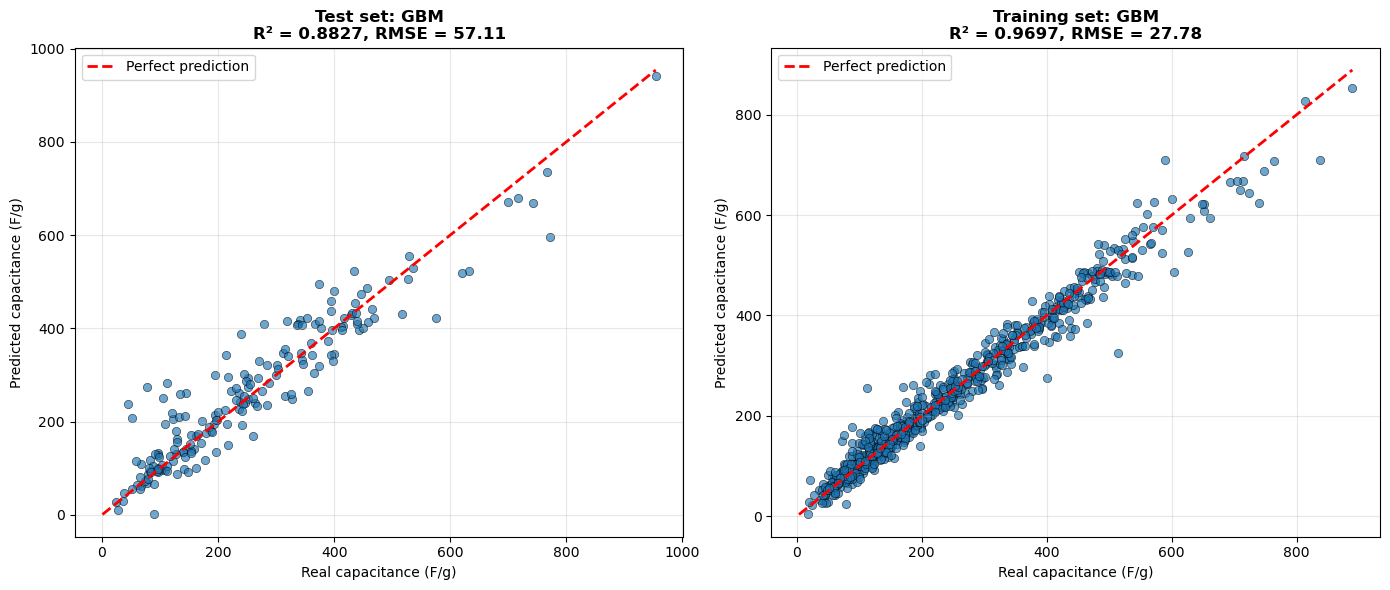

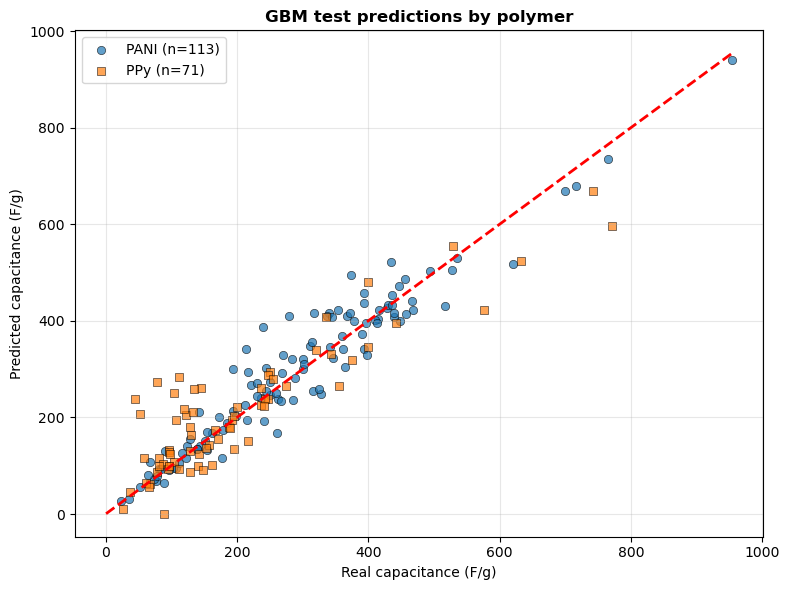


Saved model/results to: GBM


In [24]:
y_pred_train = optimized_model.predict(X_train)
y_pred_test = optimized_model.predict(X_test)


def make_prediction_frame(meta_part, split_name, y_true, y_pred):
    out = meta_part.reset_index(drop=True).copy()
    out["Split"] = split_name
    out["Real_Capacitance"] = np.asarray(y_true, dtype=float)
    out["Predicted_Capacitance"] = np.asarray(y_pred, dtype=float)
    out["Absolute_Error"] = (out["Real_Capacitance"] - out["Predicted_Capacitance"]).abs()
    eps = 1e-12
    out["Percentage_Error"] = np.where(
        np.abs(out["Real_Capacitance"]) > eps,
        out["Absolute_Error"] / np.abs(out["Real_Capacitance"]) * 100,
        np.nan,
    )
    return out

train_results_df = make_prediction_frame(meta_train, "Train", y_train, y_pred_train)
test_results_df = make_prediction_frame(meta_test, "Test", y_test, y_pred_test)
prediction_df = pd.concat([train_results_df, test_results_df], ignore_index=True)

metrics_df = build_metrics_table(prediction_df)
print("\n" + "=" * 70)
print("MODEL PERFORMANCE — ONE COMBINED GBM MODEL")
print("=" * 70)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

r2_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["R2"].iloc[0]
rmse_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["RMSE"].iloc[0]
if pd.notna(r2_gap) and r2_gap > 0.10:
    print(f"\n⚠ Possible overfitting: Train-Test R² gap = {r2_gap:.4f}; Test-Train RMSE gap = {rmse_gap:.4f}")
else:
    print("\n✓ Train-test gap looks acceptable by the 0.10 R² rule")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title, real, pred in [
    (axes[0], "Test set", y_test, y_pred_test),
    (axes[1], "Training set", y_train, y_pred_train),
]:
    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)
    r2 = metrics.r2_score(real, pred)
    rmse = np.sqrt(metrics.mean_squared_error(real, pred))
    ax.scatter(real, pred, alpha=0.65, edgecolors="k", linewidth=0.5)
    lim_min = min(np.nanmin(real), np.nanmin(pred))
    lim_max = max(np.nanmax(real), np.nanmax(pred))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Real capacitance (F/g)")
    ax.set_ylabel("Predicted capacitance (F/g)")
    ax.set_title(f"{title}: GBM\nR² = {r2:.4f}, RMSE = {rmse:.2f}", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "GBM_predictions_train_test.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 6))
plot_df = test_results_df.copy()
for scope, marker in [("PANI", "o"), ("PPy", "s")]:
    s = plot_df[plot_df[POLYMER_COL].astype(str).eq(scope)]
    plt.scatter(
        s["Real_Capacitance"], s["Predicted_Capacitance"],
        label=f"{scope} (n={len(s)})", alpha=0.7, edgecolors="k", linewidth=0.5, marker=marker,
    )
lim_min = min(plot_df["Real_Capacitance"].min(), plot_df["Predicted_Capacitance"].min())
lim_max = max(plot_df["Real_Capacitance"].max(), plot_df["Predicted_Capacitance"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2)
plt.xlabel("Real capacitance (F/g)")
plt.ylabel("Predicted capacitance (F/g)")
plt.title("GBM test predictions by polymer", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "GBM_predictions_test_by_polymer.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cv_summary_df = pd.DataFrame({
    "Item": [
        "CV description", "Best penalized CV score", "Mean CV R2 test", "Std CV R2 test",
        "Mean CV R2 train", "Std CV R2 train", "CV overfit gap", "Alpha overfit gap",
        "Best parameters",
    ],
    "Value": [
        cv_description, best_penalized, best_mean_test, best_std_test,
        best_mean_train, best_std_train, best_gap, ALPHA_OVERFIT_GAP,
        str(best_params),
    ],
})

with pd.ExcelWriter(OUTPUT_DIR / "GBM_Combined_Results.xlsx", engine="openpyxl") as writer:
    train_results_df.to_excel(writer, sheet_name="Train_Results", index=False)
    test_results_df.to_excel(writer, sheet_name="Test_Results", index=False)
    prediction_df.to_excel(writer, sheet_name="All_Predictions", index=False)
    metrics_df.to_excel(writer, sheet_name="Performance_Metrics", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="Optimized_Parameters", index=False)
    cv_summary_df.to_excel(writer, sheet_name="GridSearchCV_Summary", index=False)
    if RUN_GRID_SEARCH and not cv_results.empty:
        cv_results_to_save = cv_results.copy().sort_values("penalized_score", ascending=False)
        keep_cols = [
            "rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score",
            "overfit_gap", "penalized_score", "params",
        ]
        cv_results_to_save[keep_cols].head(200).to_excel(writer, sheet_name="GridSearch_Top200", index=False)

with open(OUTPUT_DIR / "GBM_combined_model.pkl", "wb") as f:
    pickle.dump(optimized_model, f)

print(f"\nSaved model/results to: {OUTPUT_DIR}")


## 9. SHAP functions

In [27]:
def get_transformed_feature_names_and_groups(pipeline):
    pre = pipeline.named_steps["preprocess"]
    groups = {}
    transformed_names = []

    col_idx = 0
    for f in numerical_features:
        transformed_names.append(f)
        groups[f] = [col_idx]
        col_idx += 1

    ohe = pre.named_transformers_["cat"]
    for f, cats in zip(categorical_features, ohe.categories_):
        idxs = []
        for cat in cats:
            transformed_names.append(f"{f}={cat}")
            idxs.append(col_idx)
            col_idx += 1
        groups[f] = idxs

    return transformed_names, groups


def transform_for_gbm(pipeline, X_scope):
    X_t = pipeline.named_steps["preprocess"].transform(X_scope)
    if hasattr(X_t, "toarray"):
        X_t = X_t.toarray()
    transformed_names, _ = get_transformed_feature_names_and_groups(pipeline)
    return pd.DataFrame(np.asarray(X_t, dtype=float), columns=transformed_names, index=X_scope.index)


def aggregate_encoded_shap(shap_values_encoded, groups):
    agg = np.zeros((shap_values_encoded.shape[0], len(feature_names)), dtype=float)
    for j, f in enumerate(feature_names):
        idxs = groups[f]
        agg[:, j] = shap_values_encoded[:, idxs].sum(axis=1)
    return agg


def compute_gbm_shap_values(pipeline, X_scope):
    """Return approximate TreeSHAP values aggregated back to original feature names."""
    X_scope = X_scope.copy()
    predictions = pipeline.predict(X_scope)
    X_t = transform_for_gbm(pipeline, X_scope)
    _, groups = get_transformed_feature_names_and_groups(pipeline)
    gbm_model = pipeline.named_steps["model"]

    explainer = shap.TreeExplainer(gbm_model)
    shap_values_encoded = explainer.shap_values(
        X_t,
        approximate=SHAP_APPROXIMATE,
        check_additivity=False,
    )
    if isinstance(shap_values_encoded, list):
        shap_values_encoded = shap_values_encoded[0]
    shap_values_encoded = np.asarray(shap_values_encoded, dtype=float)

    expected_value = float(np.asarray(explainer.expected_value).ravel()[0])
    base_values = np.full(X_scope.shape[0], expected_value, dtype=float)
    method = f"shap.TreeExplainer(sklearn GradientBoostingRegressor encoded features; approximate={SHAP_APPROXIMATE})"

    shap_values = aggregate_encoded_shap(shap_values_encoded, groups)
    additive_error = float(np.nanmax(np.abs(predictions - (base_values + shap_values.sum(axis=1)))))
    return shap_values, base_values, method, additive_error


def save_shap_scope(scope_name, model, X_scope, y_scope, meta_scope, output_dir):
    scope_dir = Path(output_dir) / f"SHAP_{clean_filename(scope_name)}"
    scope_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nCalculating GBM SHAP values for {scope_name} (n={len(X_scope)})...")
    if len(X_scope) == 0:
        print(f"SHAP scope {scope_name}: no rows; skipped.")
        return pd.DataFrame(columns=["Scope", "Feature", "Feature_Type", "MeanAbsSHAP", "MeanSHAP"])

    shap_values, base_values, method, additive_error = compute_gbm_shap_values(model, X_scope)
    predictions = model.predict(X_scope)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    mean_shap = shap_values.mean(axis=0)
    mean_abs_df = pd.DataFrame({
        "Scope": scope_name,
        "Feature": feature_names,
        "Feature_Type": ["Categorical" if f in categorical_features else "Numerical" for f in feature_names],
        "MeanAbsSHAP": mean_abs_shap,
        "MeanSHAP": mean_shap,
    }).sort_values("MeanAbsSHAP", ascending=False)

    shap_value_df = meta_scope.reset_index(drop=True).copy()
    shap_value_df["Real_Capacitance"] = np.asarray(y_scope, dtype=float)
    shap_value_df["Predicted_Capacitance"] = predictions
    shap_value_df["Base_Value"] = base_values
    for i, feat in enumerate(feature_names):
        shap_value_df[f"SHAP_{feat}"] = shap_values[:, i]

    feature_value_df = meta_scope.reset_index(drop=True).copy()
    X_reset = X_scope.reset_index(drop=True)
    for feat in feature_names:
        feature_value_df[feat] = X_reset[feat].astype(str).values if feat in categorical_features else X_reset[feat].values

    long_rows = []
    for i, feat in enumerate(feature_names):
        tmp = pd.DataFrame({
            "Scope": scope_name,
            "Record_ID": meta_scope.reset_index(drop=True)["Record_ID"].values,
            "Feature": feat,
            "Feature_Type": "Categorical" if feat in categorical_features else "Numerical",
            "Feature_Value": X_reset[feat].astype(str).values if feat in categorical_features else X_reset[feat].values,
            "SHAP_Value": shap_values[:, i],
        })
        long_rows.append(tmp)
    long_df = pd.concat(long_rows, ignore_index=True)

    info_df = pd.DataFrame({
        "Item": ["Scope", "Rows", "SHAP method", "Max additive error", "Note"],
        "Value": [
            scope_name,
            len(X_scope),
            method,
            additive_error,
            "Categorical one-hot SHAP values aggregated to original feature names. With approximate=True, additive error is expected and reported.",
        ],
    })

    with pd.ExcelWriter(scope_dir / f"{clean_filename(scope_name)}_SHAP.xlsx", engine="openpyxl") as writer:
        info_df.to_excel(writer, sheet_name="Info", index=False)
        mean_abs_df.to_excel(writer, sheet_name="MeanAbsSHAP", index=False)
        shap_value_df.to_excel(writer, sheet_name="SHAP_Values", index=False)
        feature_value_df.to_excel(writer, sheet_name="Feature_Values", index=False)
        long_df.to_excel(writer, sheet_name="Long_Format", index=False)

    plt.figure(figsize=(10, 7))
    plot_df = mean_abs_df.sort_values("MeanAbsSHAP", ascending=True)
    colors = ["#E63975" if f in categorical_features else "#2E5090" for f in plot_df["Feature"]]
    plt.barh(plot_df["Feature"], plot_df["MeanAbsSHAP"], color=colors, edgecolor="white")
    plt.xlabel("Mean absolute SHAP value (F/g)")
    plt.ylabel("Feature")
    plt.title(f"{scope_name}: mean absolute SHAP values — GBM", fontweight="bold")
    legend_elems = [Patch(facecolor="#2E5090", label="Numerical"), Patch(facecolor="#E63975", label="Categorical")]
    plt.legend(handles=legend_elems, loc="lower right")
    plt.tight_layout()
    plt.savefig(scope_dir / f"{clean_filename(scope_name)}_MeanAbsSHAP.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    if WRITE_PER_FEATURE_SHAP_PLOTS:
        for feat in numerical_features:
            i = feature_names.index(feat)
            plt.figure(figsize=(8, 6))
            plt.scatter(X_scope[feat], shap_values[:, i], alpha=0.65, edgecolors="k", linewidth=0.5)
            plt.axhline(0, color="red", lw=1, ls="--")
            plt.xlabel(feat)
            plt.ylabel("Aggregated SHAP value (F/g)")
            plt.title(f"{scope_name}: SHAP values for {feat} — GBM", fontweight="bold")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(scope_dir / f"{clean_filename(scope_name)}_SHAP_{clean_filename(feat)}.png", dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()

        for feat in categorical_features:
            i = feature_names.index(feat)
            cat_values = X_scope[feat].astype(str).values
            unique_classes = sorted(pd.unique(cat_values))
            data_per_class = [shap_values[cat_values == c, i] for c in unique_classes]
            plt.figure(figsize=(max(8, 0.8 * len(unique_classes)), 6))
            bp = safe_boxplot(data_per_class, unique_classes, patch_artist=True)
            for patch in bp["boxes"]:
                patch.set_facecolor("#E63975")
                patch.set_alpha(0.55)
            plt.axhline(0, color="red", lw=1, ls="--")
            plt.xlabel(feat)
            plt.ylabel("Aggregated SHAP value (F/g)")
            plt.title(f"{scope_name}: SHAP values by class for {feat} — GBM", fontweight="bold")
            plt.grid(True, alpha=0.3, axis="y")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.savefig(scope_dir / f"{clean_filename(scope_name)}_SHAP_{clean_filename(feat)}.png", dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()

    print(f"Saved GBM SHAP outputs for {scope_name}: {scope_dir}")
    return mean_abs_df


## 10. Run SHAP for All, PANI, and PPy


Calculating GBM SHAP values for All (n=917)...


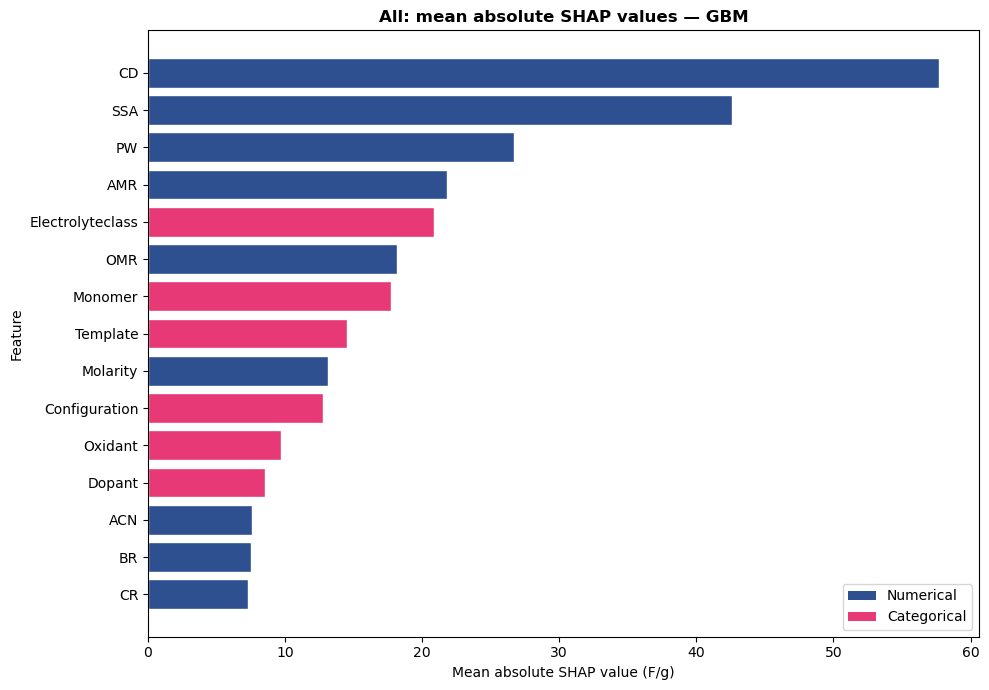

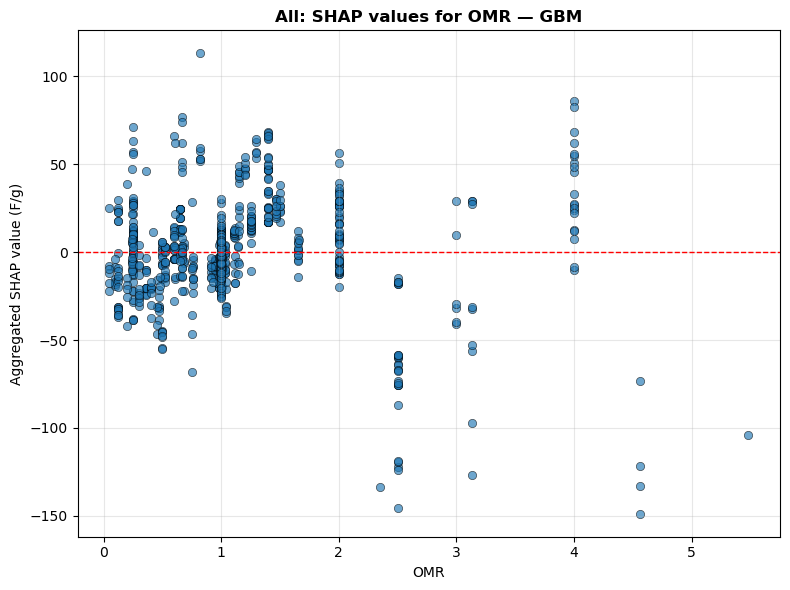

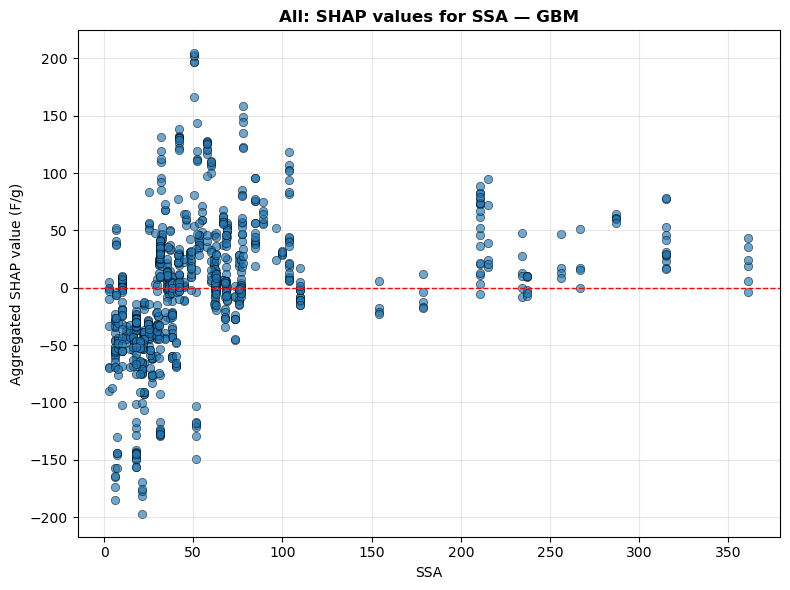

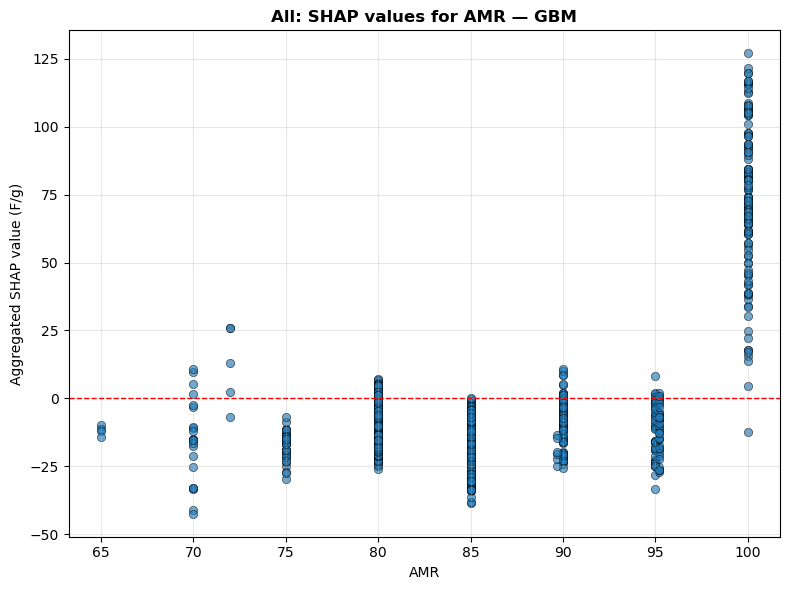

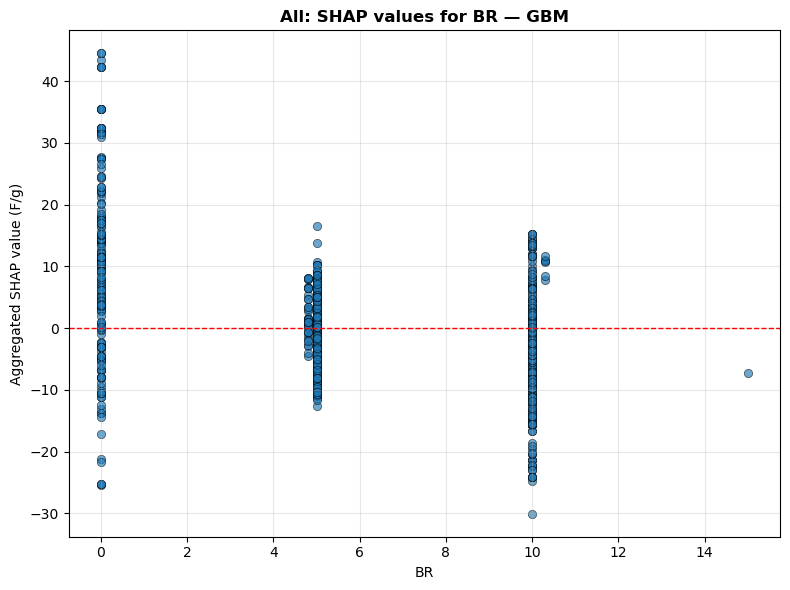

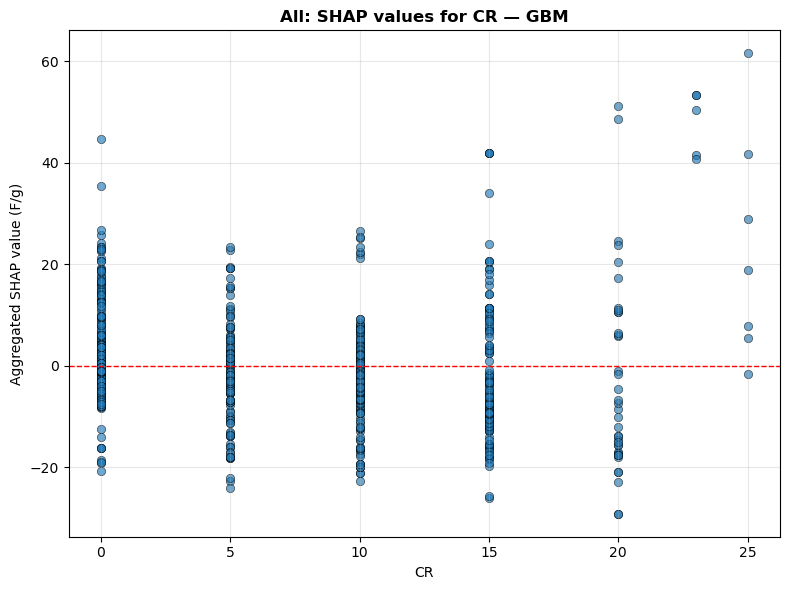

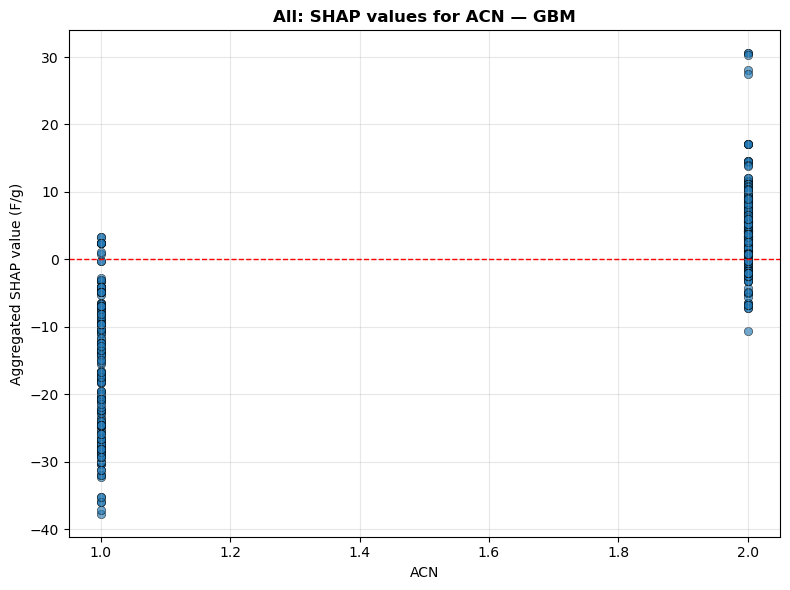

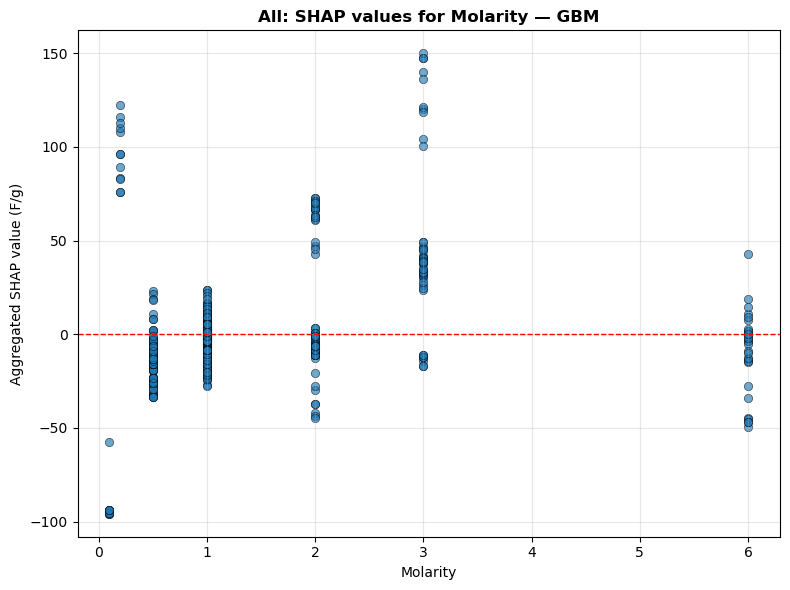

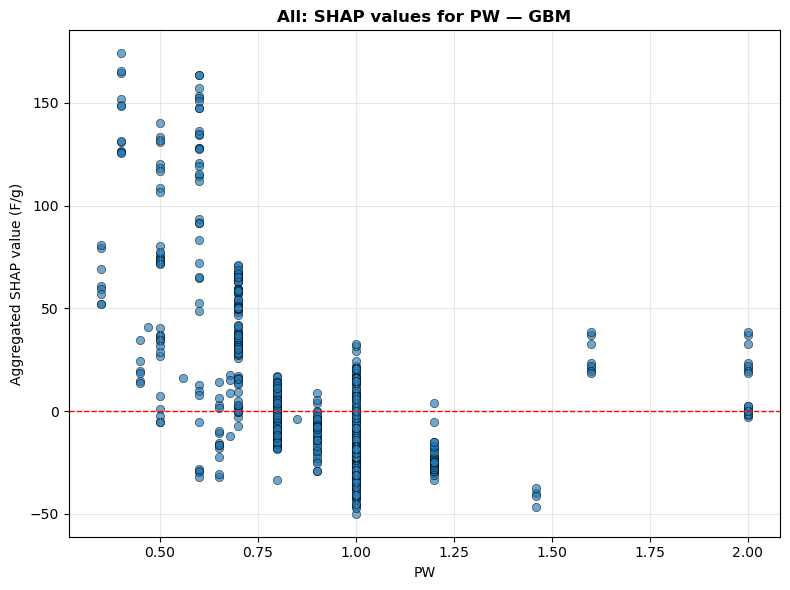

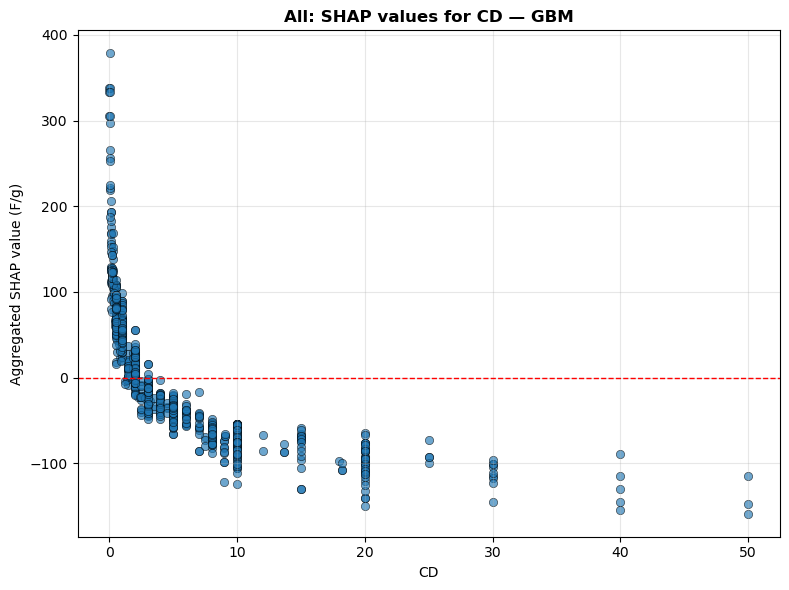

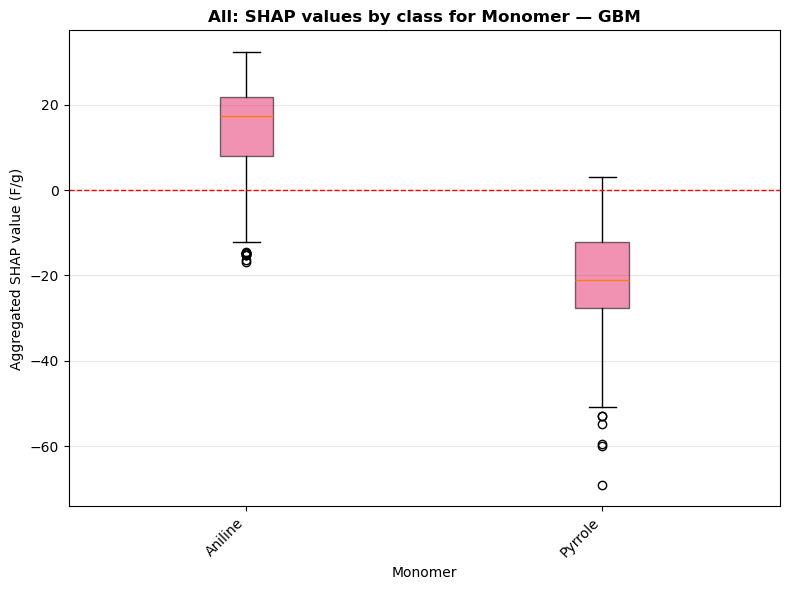

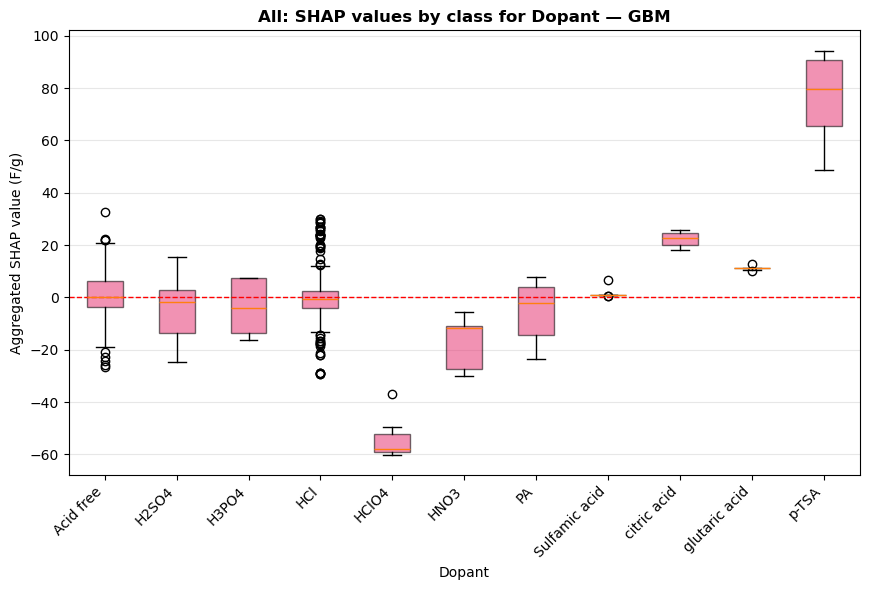

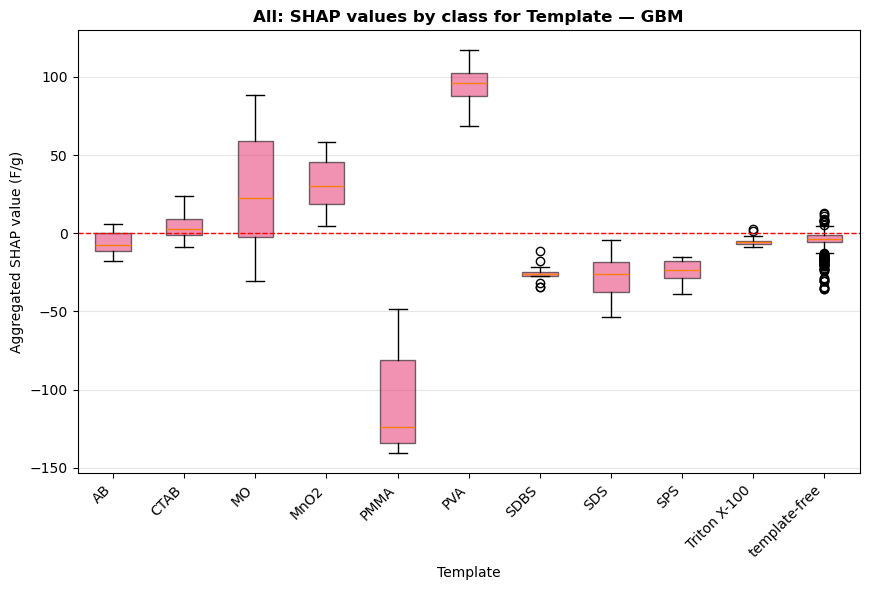

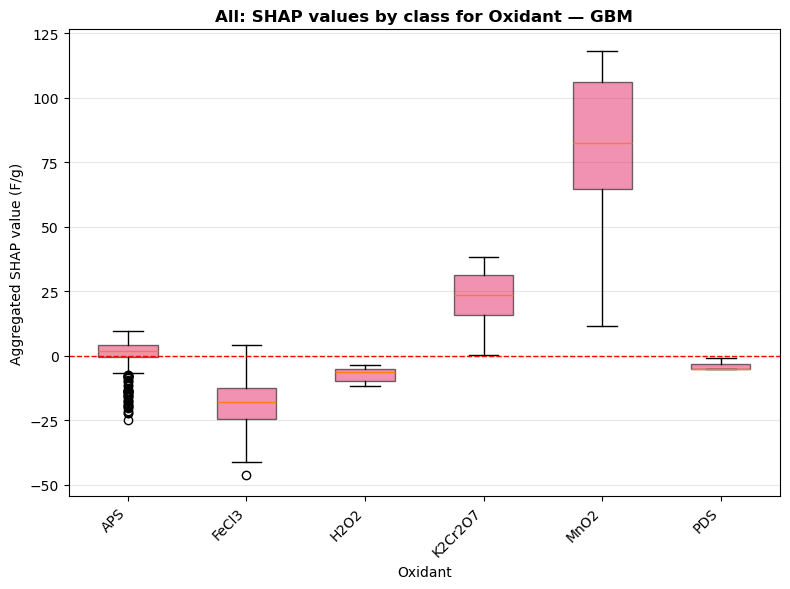

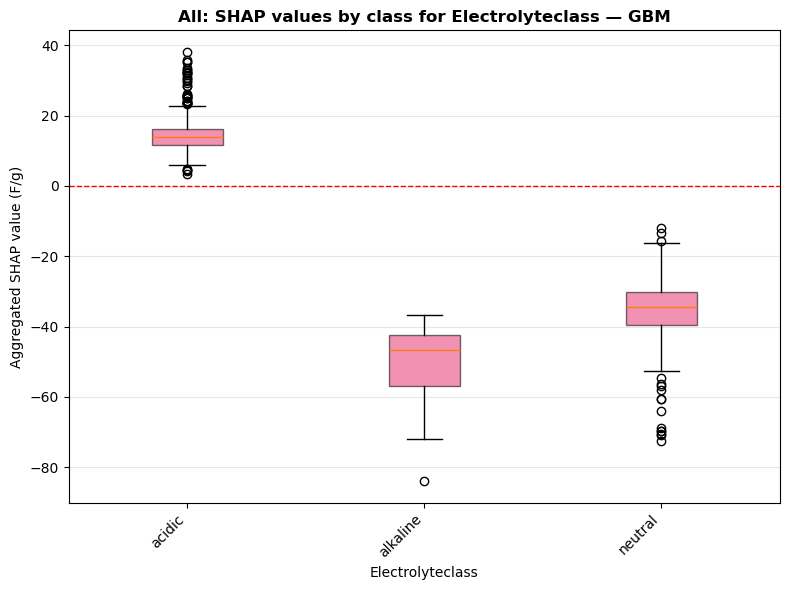

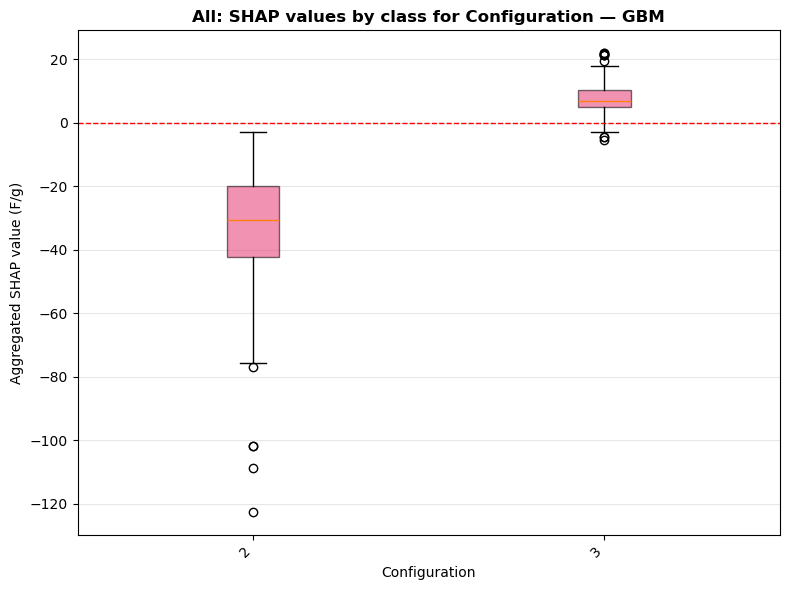

Saved GBM SHAP outputs for All: GBM\SHAP_All

PANI SHAP rows: 541

Calculating GBM SHAP values for PANI (n=541)...


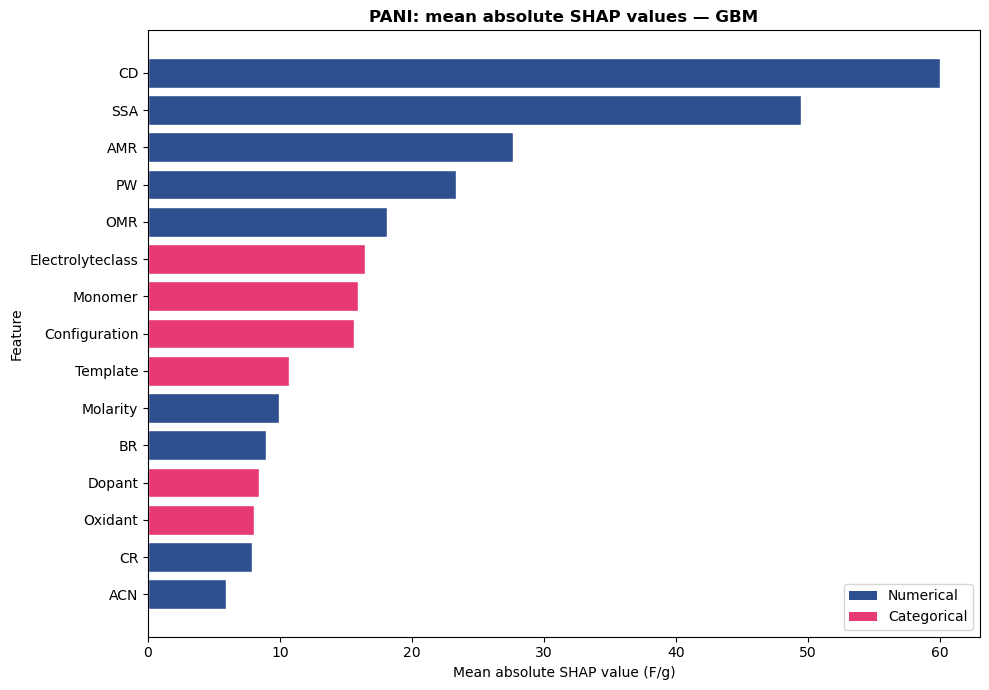

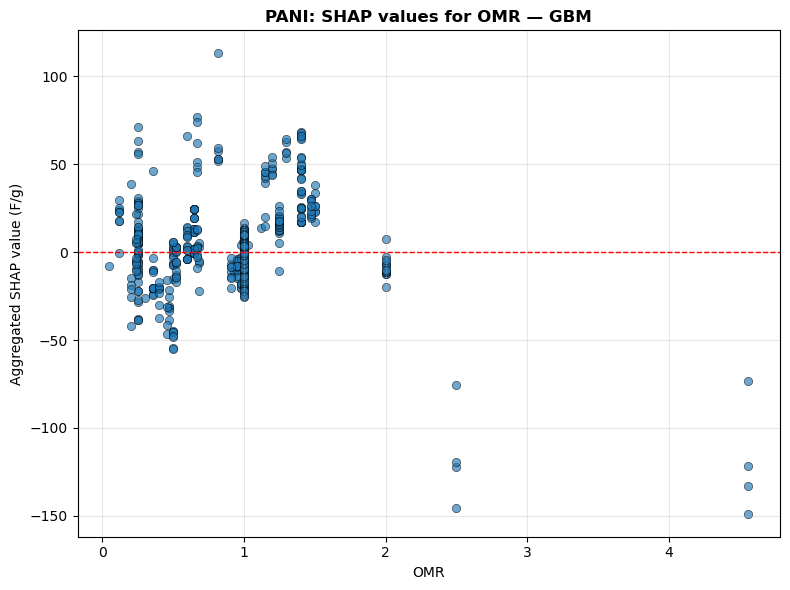

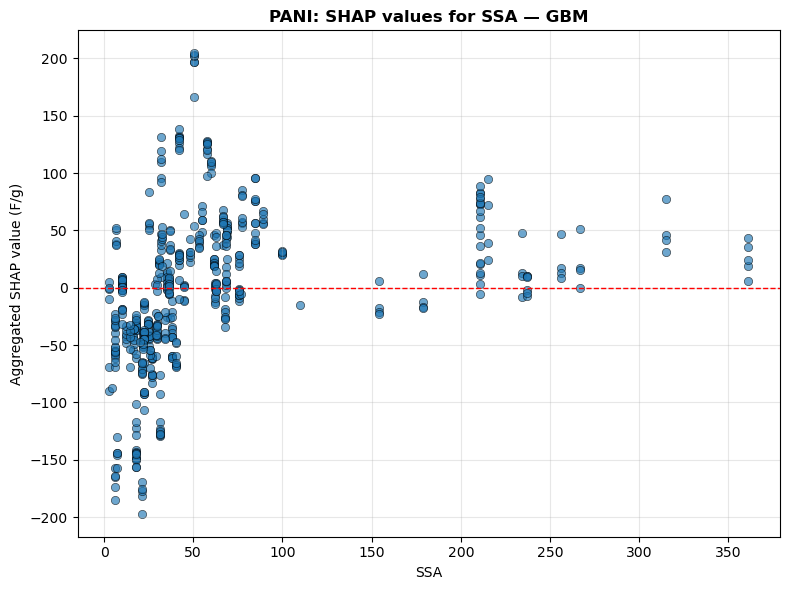

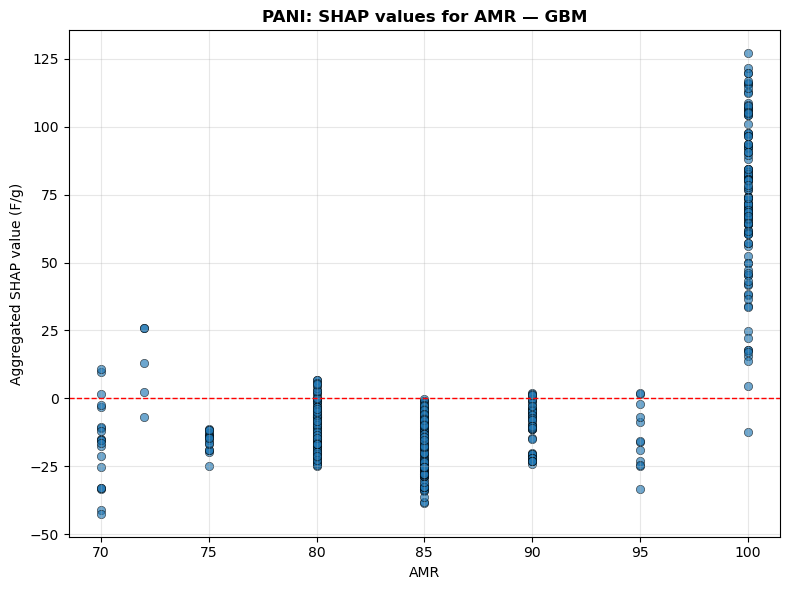

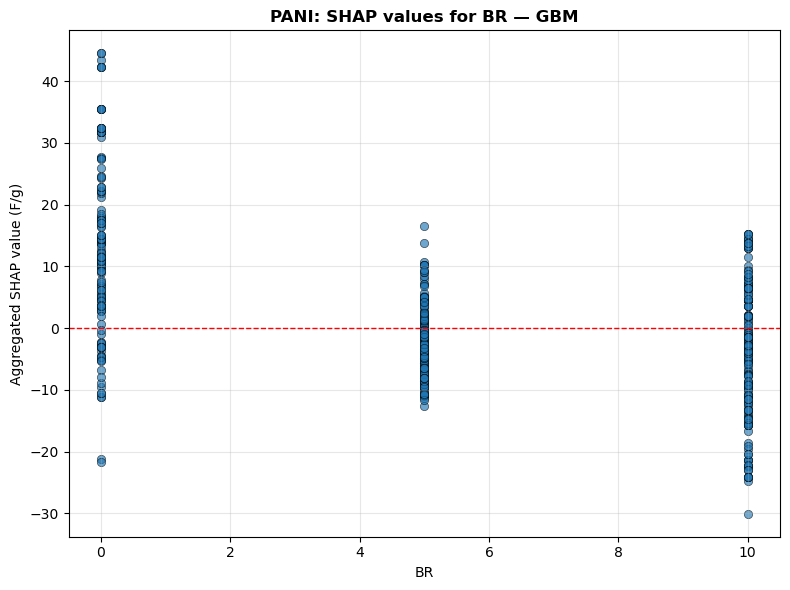

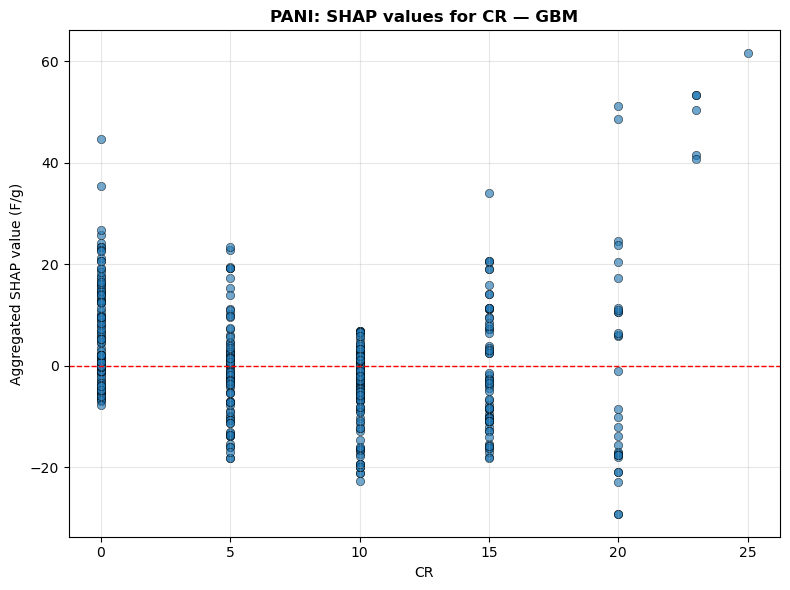

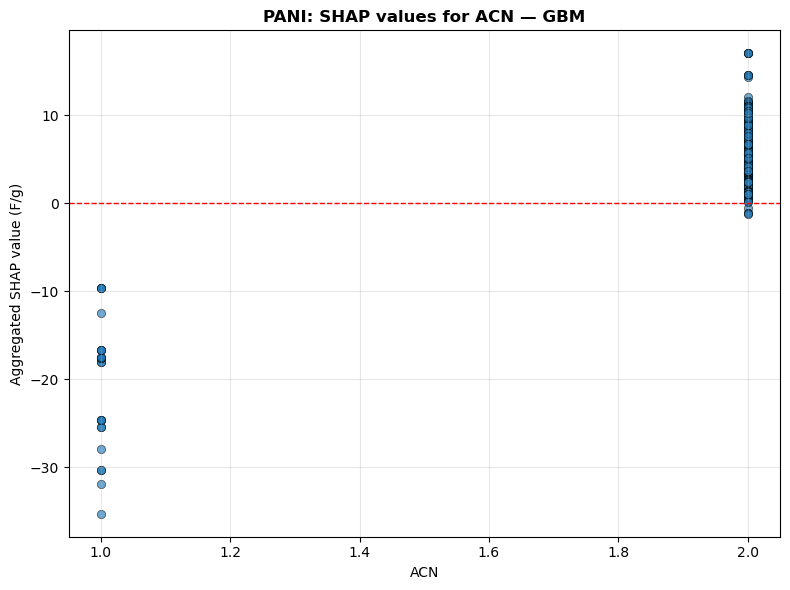

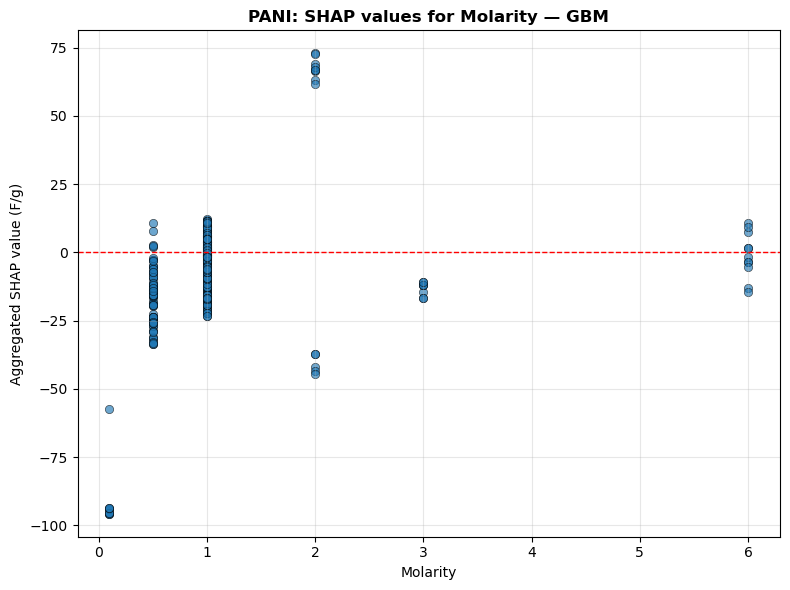

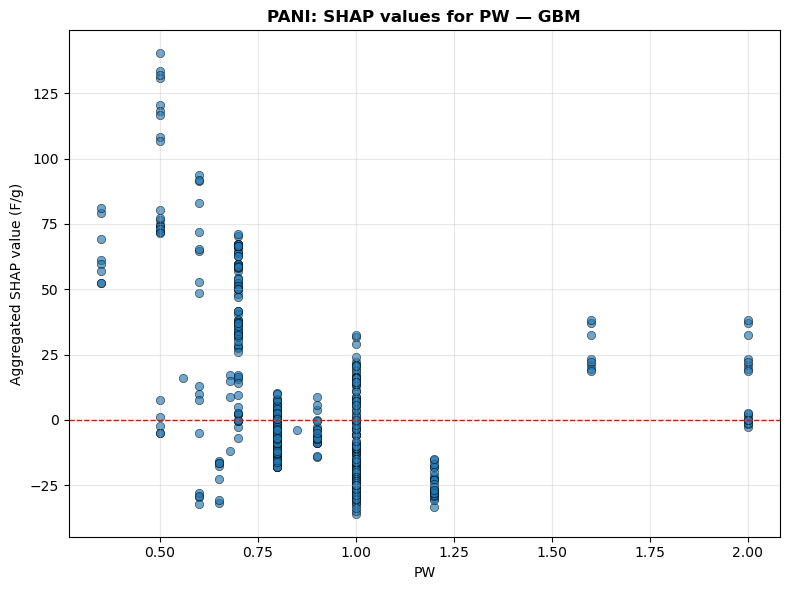

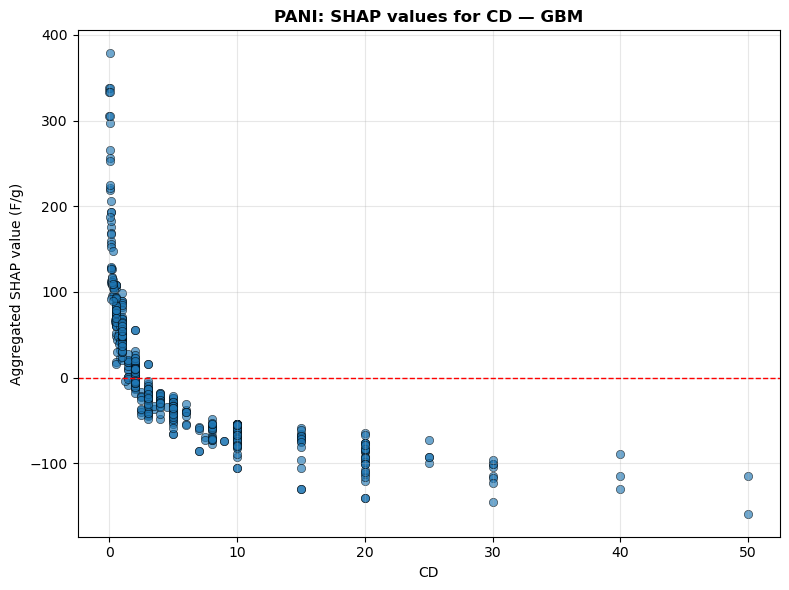

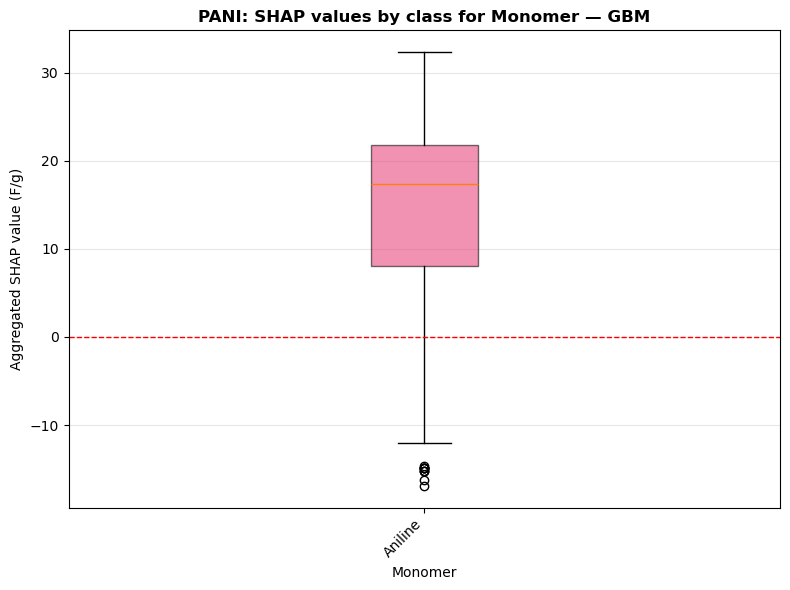

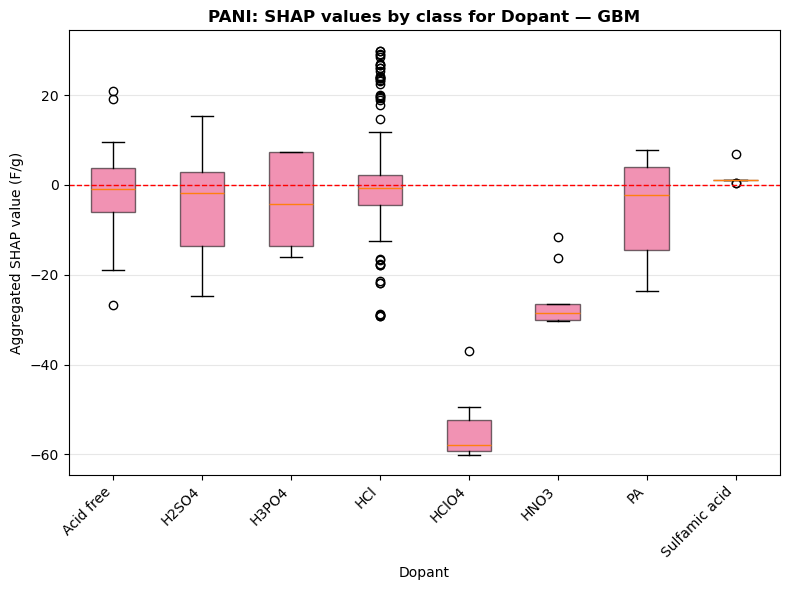

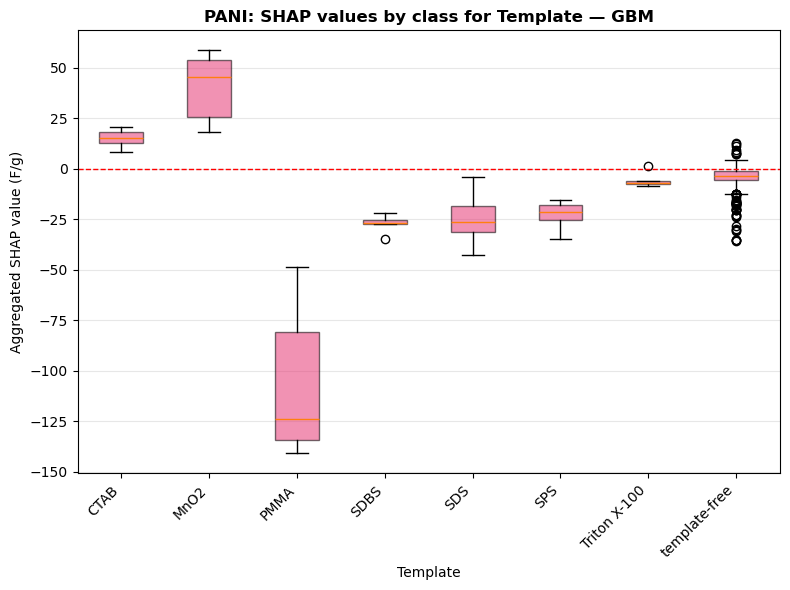

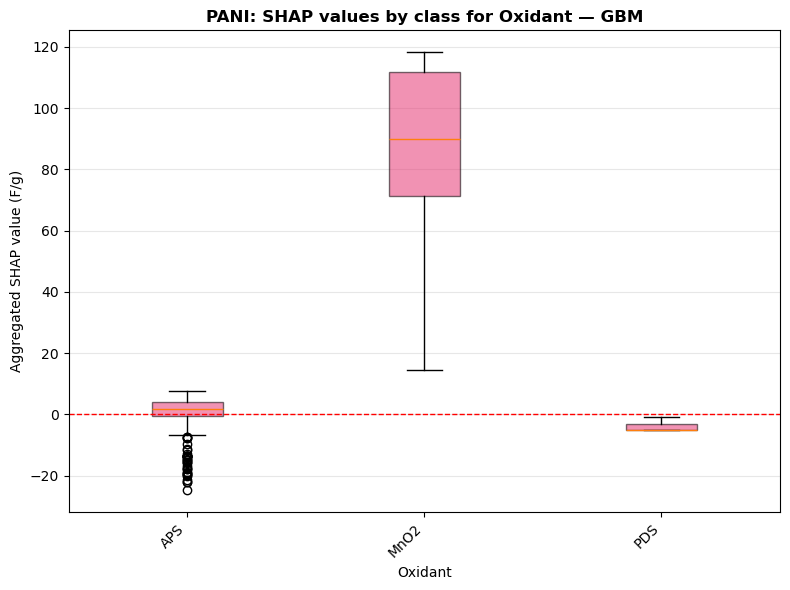

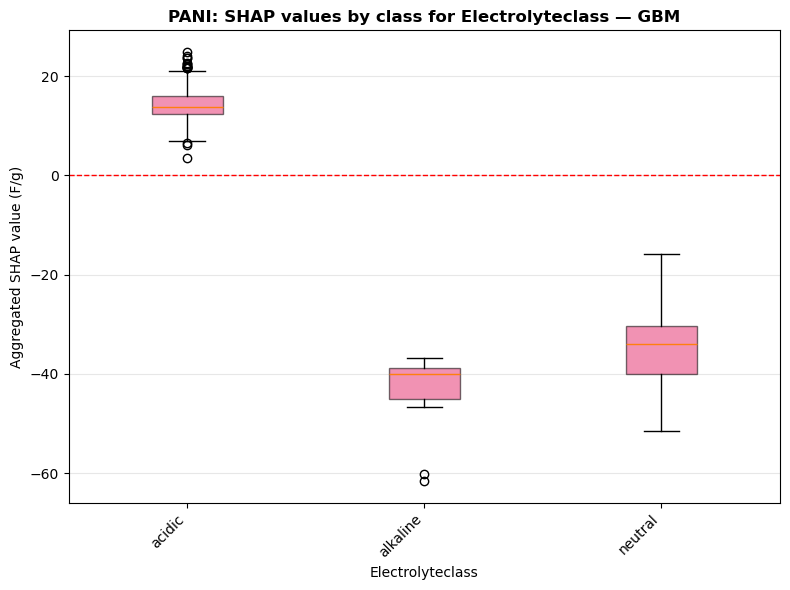

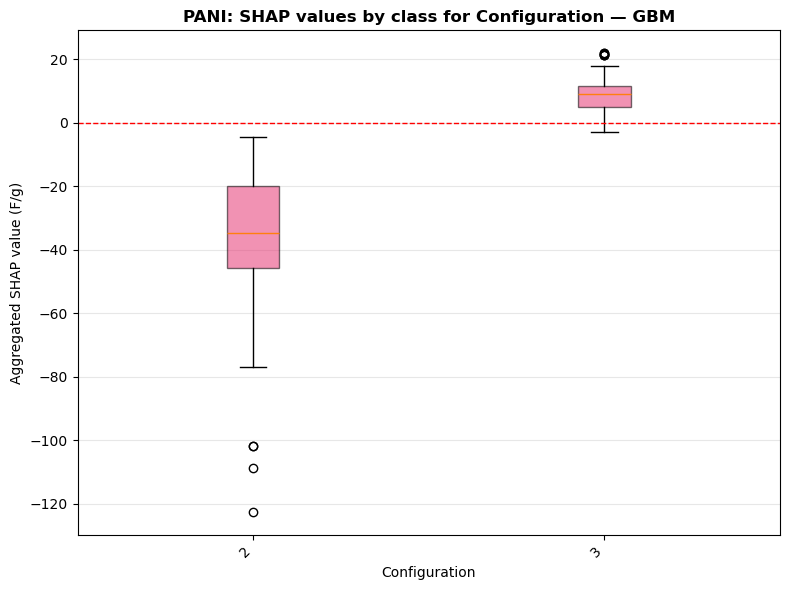

Saved GBM SHAP outputs for PANI: GBM\SHAP_PANI

PPy SHAP rows: 376

Calculating GBM SHAP values for PPy (n=376)...


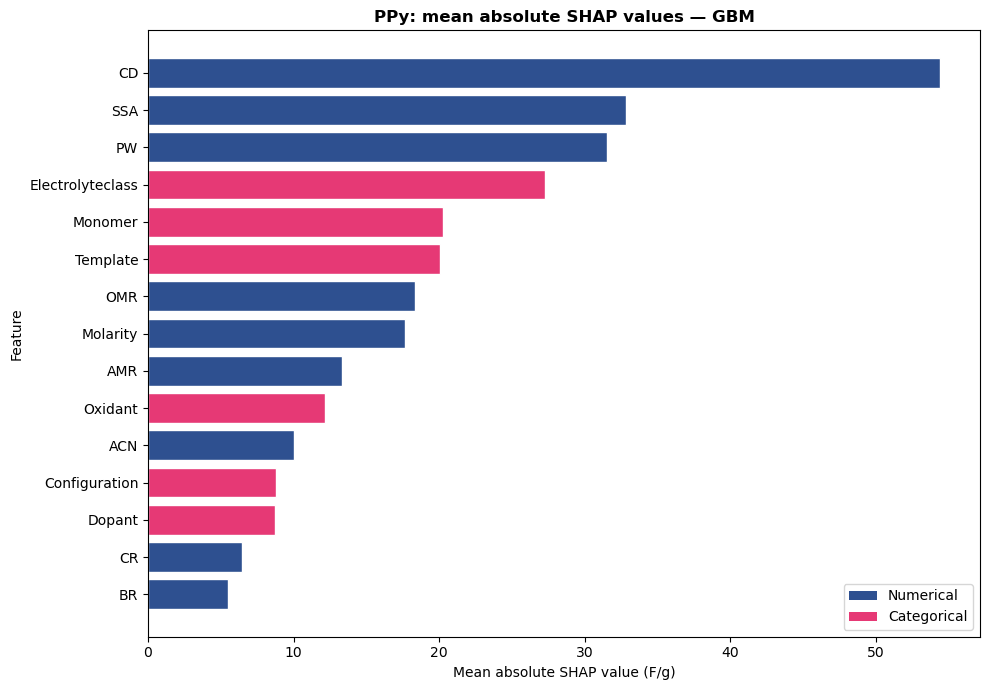

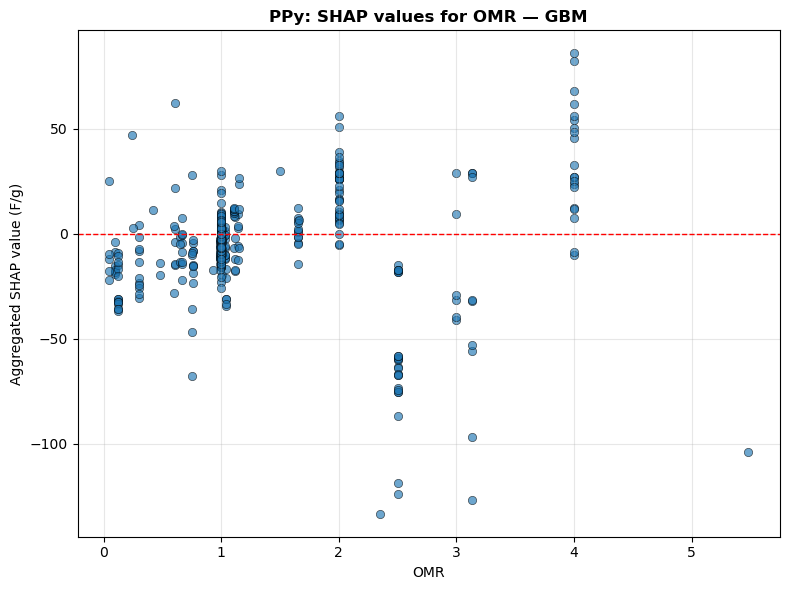

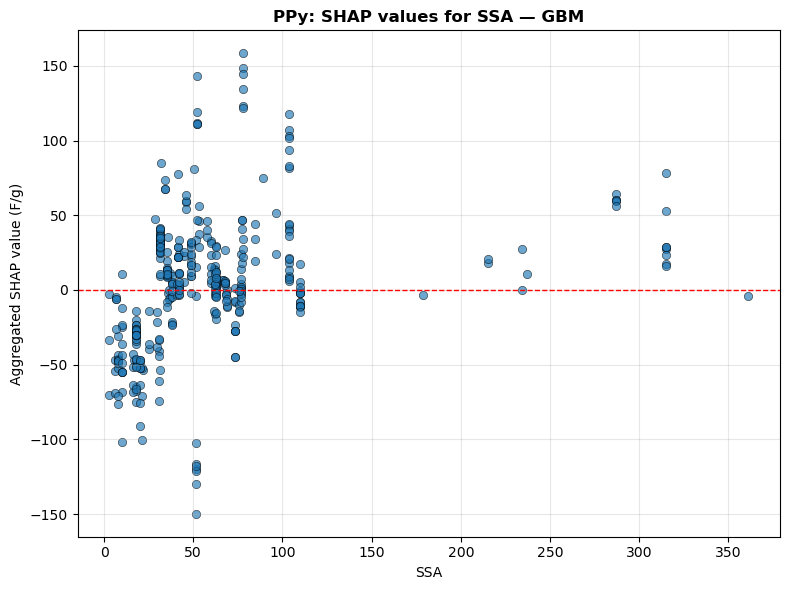

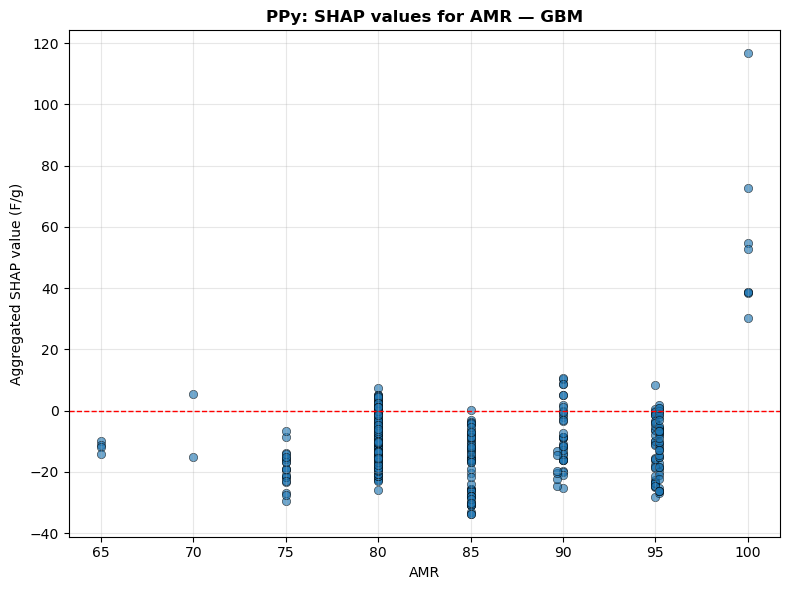

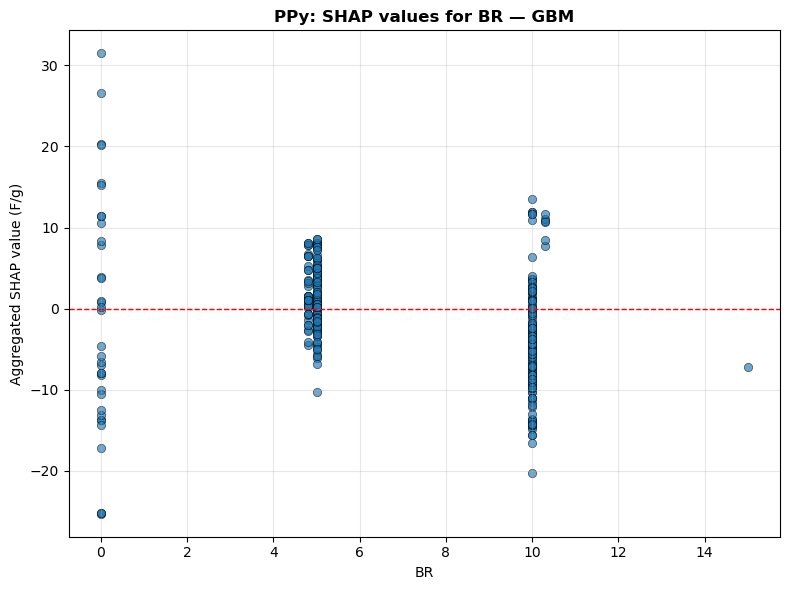

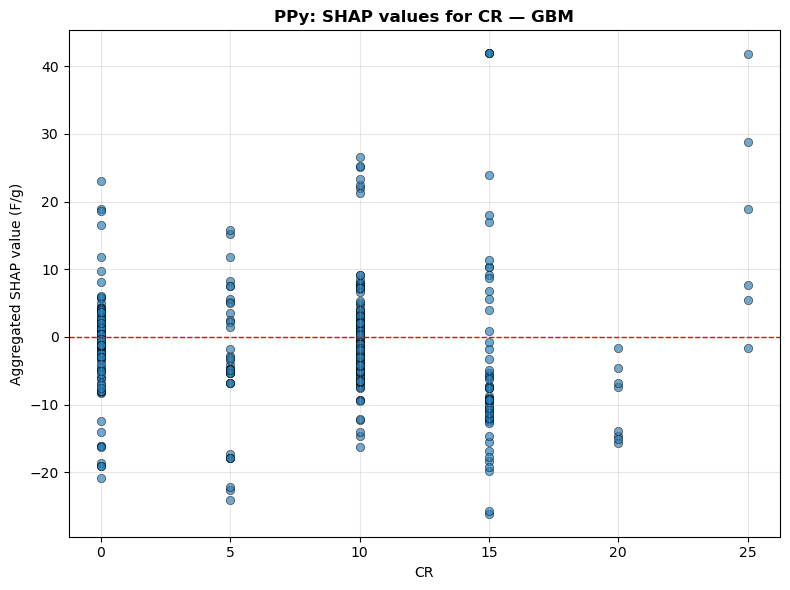

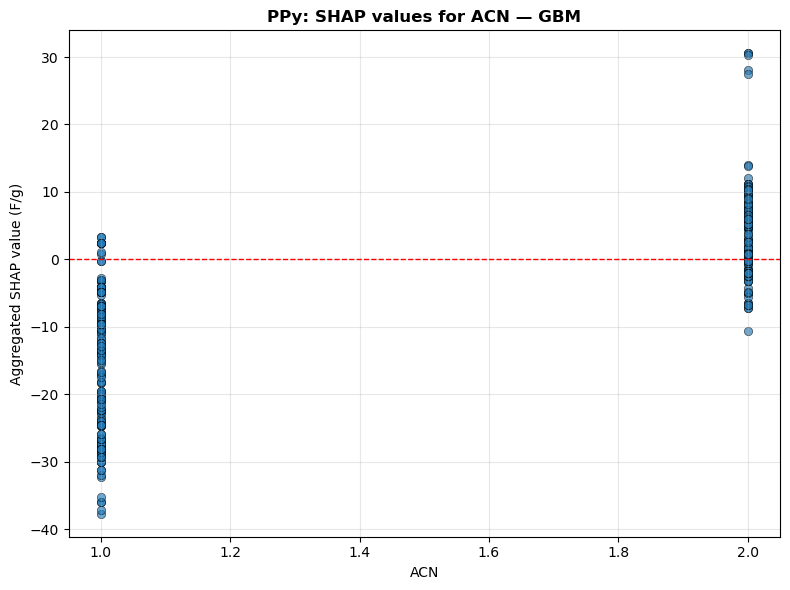

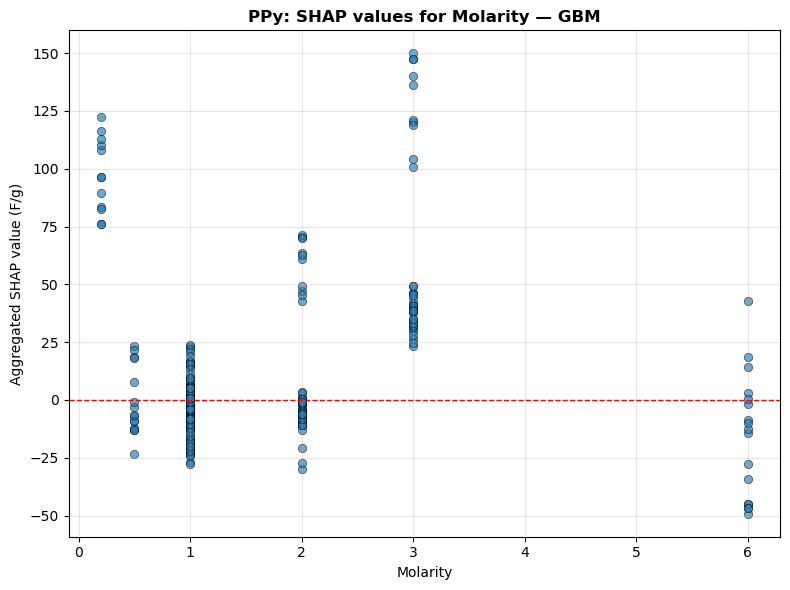

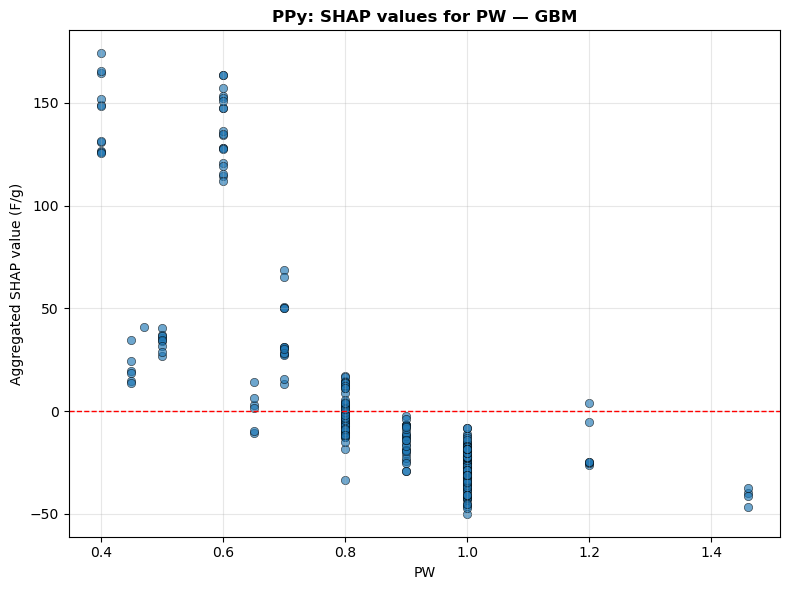

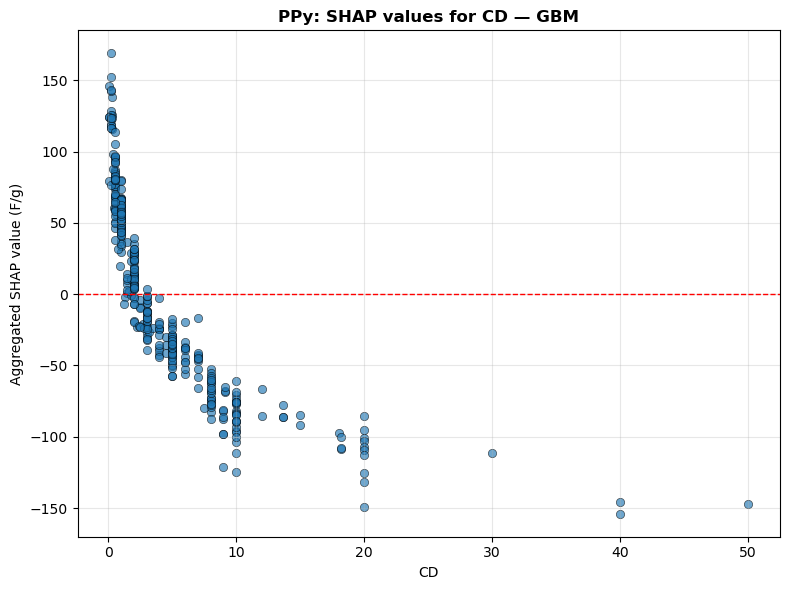

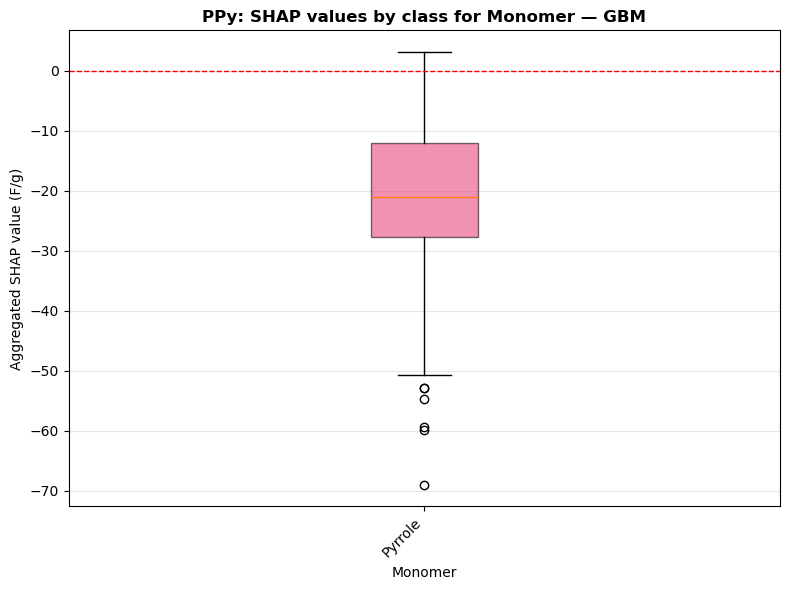

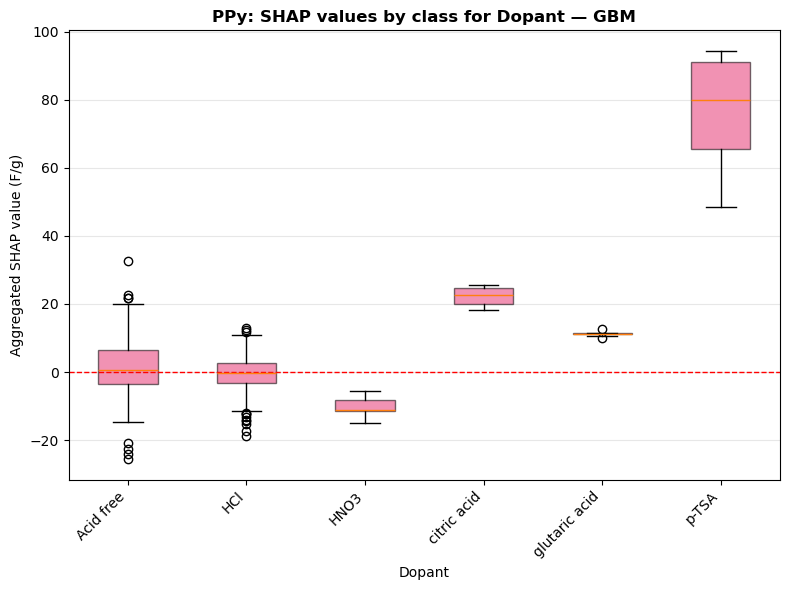

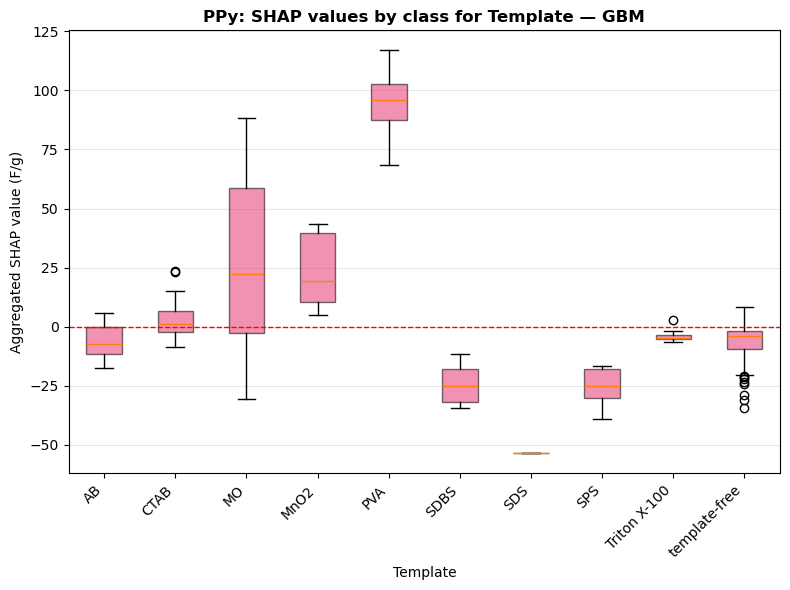

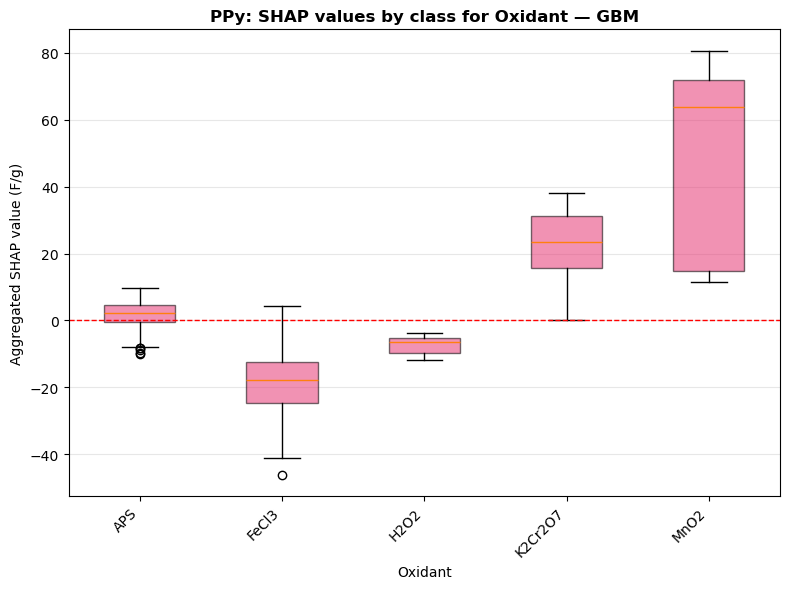

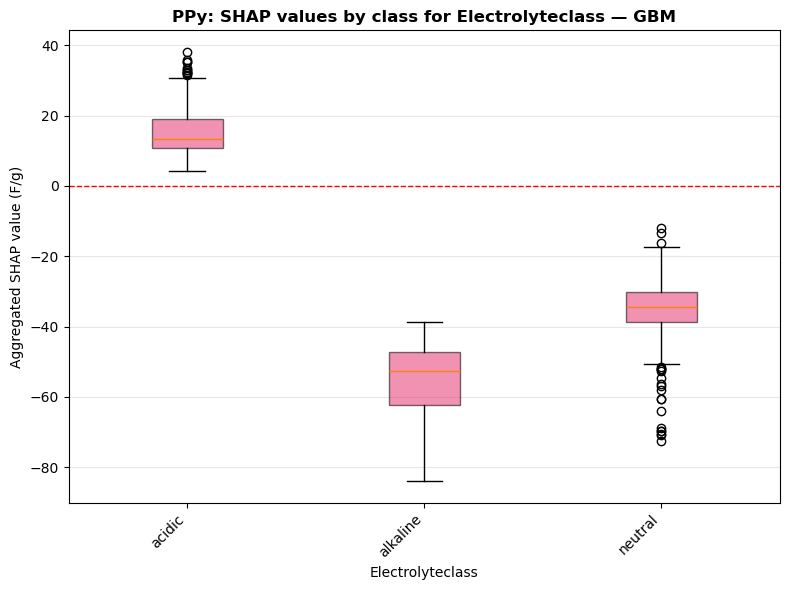

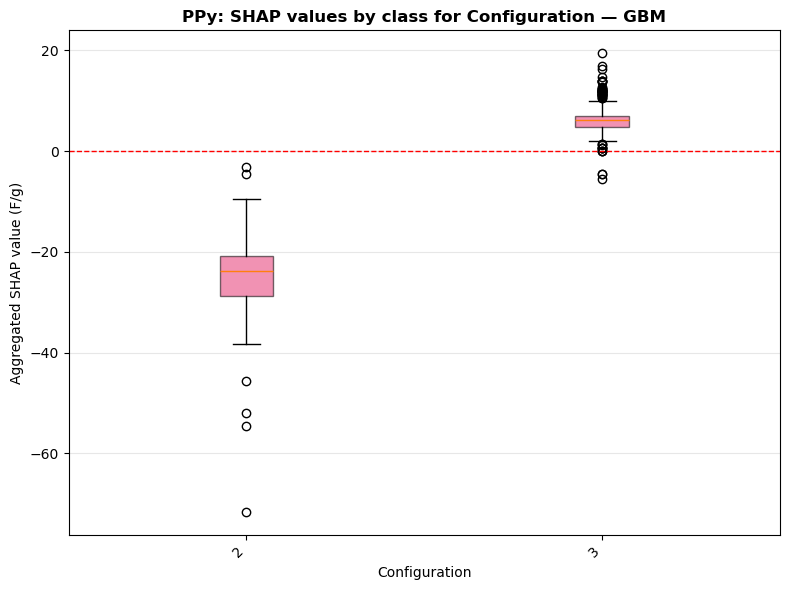

Saved GBM SHAP outputs for PPy: GBM\SHAP_PPy


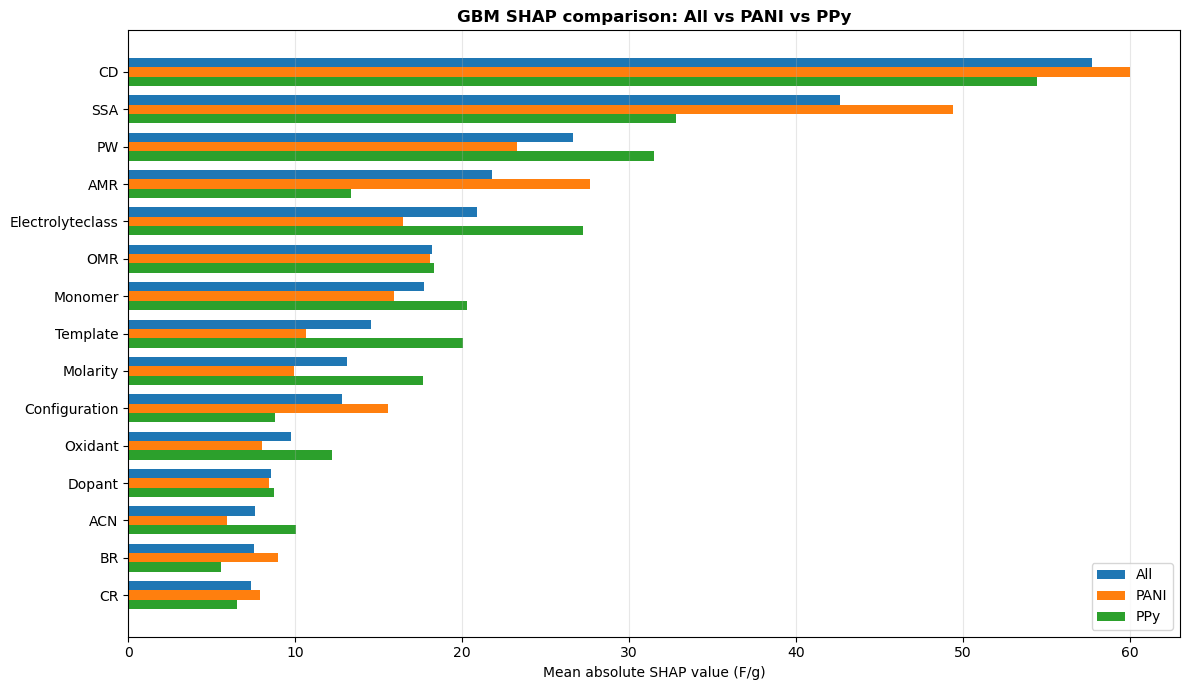


GBM SHAP comparison saved.


In [30]:
shap_mean_tables = {}

shap_mean_tables["All"] = save_shap_scope(
    scope_name="All",
    model=optimized_model,
    X_scope=X,
    y_scope=y,
    meta_scope=meta,
    output_dir=OUTPUT_DIR,
)

for scope in ["PANI", "PPy"]:
    mask = meta[POLYMER_COL].astype(str).eq(scope)
    print(f"\n{scope} SHAP rows: {int(mask.sum())}")
    shap_mean_tables[scope] = save_shap_scope(
        scope_name=scope,
        model=optimized_model,
        X_scope=X.loc[mask].copy(),
        y_scope=y.loc[mask].copy(),
        meta_scope=meta.loc[mask].copy(),
        output_dir=OUTPUT_DIR,
    )

comparison_df = pd.DataFrame({"Feature": feature_names})
comparison_df["Feature_Type"] = ["Categorical" if f in categorical_features else "Numerical" for f in feature_names]
for scope, table in shap_mean_tables.items():
    vals = table[["Feature", "MeanAbsSHAP"]].rename(columns={"MeanAbsSHAP": scope})
    comparison_df = comparison_df.merge(vals, on="Feature", how="left")

comparison_df = comparison_df.sort_values("All", ascending=False)
comparison_df.to_excel(OUTPUT_DIR / "SHAP_MeanAbs_Comparison_All_PANI_PPy.xlsx", index=False)

plt.figure(figsize=(12, 7))
plot_features = comparison_df["Feature"].tolist()
y_pos = np.arange(len(plot_features))
bar_h = 0.25
for offset, scope in [(-bar_h, "All"), (0, "PANI"), (bar_h, "PPy")]:
    plt.barh(y_pos + offset, comparison_df[scope], height=bar_h, label=scope)
plt.yticks(y_pos, plot_features)
plt.gca().invert_yaxis()
plt.xlabel("Mean absolute SHAP value (F/g)")
plt.title("GBM SHAP comparison: All vs PANI vs PPy", fontweight="bold")
plt.grid(True, alpha=0.3, axis="x")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SHAP_MeanAbs_Comparison_All_PANI_PPy.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("\nGBM SHAP comparison saved.")


## 11. Supported 2D-PDP interaction residual screening

In [33]:

if RUN_PDP2D_INTERACTIONS:
    PDP2D_DIR = OUTPUT_DIR / "PDP2D_supported_interaction_residuals"
    PDP2D_DIR.mkdir(parents=True, exist_ok=True)

    INTERACTION_CANDIDATE_PAIRS = [
        ("OMR", "Electrolyteclass"),  
        ("SSA", "CD"),              
        ("OMR", "PW"),               
        ("OMR", "Template"),          
        ("PW", "SSA"),                 
        ("OMR", "SSA"),                
        ("ACN", "Electrolyteclass"),   
        ("Molarity", "Electrolyteclass"),
        ("OMR", "Oxidant"),           
    ]


    MAIN_TEXT_ELIGIBLE_PAIRS = {
        tuple(p) for p in [
            ("OMR", "Electrolyteclass"),
            ("SSA", "CD"),
            ("OMR", "PW"),
            ("PW", "SSA"),
            ("OMR", "SSA"),
        ]
    }
    DIAGNOSTIC_OR_SI_FIRST_PAIRS = {
        tuple(p) for p in [
            ("OMR", "Template"),
            ("ACN", "Electrolyteclass"),
            ("Molarity", "Electrolyteclass"),
            ("OMR", "Oxidant"),
        ]
    }

    MIN_UNIQUE_SETTINGS_FOR_SUPPORTED_CELL = int(MIN_CELL_N_FOR_SUPPORTED_PDP2D)
    MIN_SUPPORTED_CELLS_FOR_PAIR_SUMMARY = 2
    TOP_MAIN_TEXT_PAIR_COUNT = 2
    DISPLAY_PDP2D_PLOTS_IN_NOTEBOOK = False


    NUMERIC_BIN_DEFINITIONS = {
        "OMR": {
            "edges": [-np.inf, 1.0, 1.5, 2.0, np.inf],
            "labels": ["OMR ≤ 1", "1 < OMR ≤ 1.5", "1.5 < OMR ≤ 2", "OMR > 2"],
            "right": True,
        },
        "SSA": {
            "edges": [-np.inf, 30.0, 50.0, 100.0, 200.0, np.inf],
            "labels": ["SSA ≤ 30", "30–50", "50–100", "100–200", ">200"],
            "right": True,
        },
        "PW": {
            "edges": [-np.inf, 0.6, 0.9, 1.2, np.inf],
            "labels": ["PW ≤ 0.6", "0.6–0.9", "0.9–1.2", ">1.2"],
            "right": True,
        },
        "CD": {
            "edges": [-np.inf, 0.5, 1.0, 2.0, 5.0, 10.0, np.inf],
            "labels": ["CD ≤ 0.5", "0.5–1", "1–2", "2–5", "5–10", ">10"],
            "right": True,
        },
    }

    def is_categorical_feature(feature):
        return feature in categorical_features

    def canonical_pair(pair):
        return tuple(pair)

    def pair_label(pair):
        return f"{pair[0]} × {pair[1]}"

    def display_value(feature, value):
        if pd.isna(value):
            return "NA"
        if feature == "ACN":
            try:
                val = float(value)
                if np.isclose(abs(val), 2.0):
                    return "ACN = 2"
                if np.isclose(abs(val), 1.0):
                    return "ACN = 1"
            except Exception:
                pass
        try:
            value_float = float(value)
            if abs(value_float - round(value_float)) < 1e-9:
                return str(int(round(value_float)))
            return f"{value_float:.4g}"
        except Exception:
            return str(value)

    def clean_axis_label(feature):
        label_map = {
            "OMR": "OMR",
            "SSA": "SSA (m² g⁻¹)",
            "PW": "PW (V)",
            "CD": "CD (A g⁻¹)",
            "Molarity": "Molarity (M)",
            "ACN": "ACN",
            "Electrolyteclass": "Electrolyte class",
        }
        return label_map.get(feature, feature)

    def _bin_mask(series, edges, idx, right=True):
        s = pd.to_numeric(series, errors="coerce")
        lower = edges[idx]
        upper = edges[idx + 1]
        if right:
            left_ok = np.ones(len(s), dtype=bool) if np.isneginf(lower) else (s > lower)
            right_ok = np.ones(len(s), dtype=bool) if np.isposinf(upper) else (s <= upper)
        else:
            left_ok = np.ones(len(s), dtype=bool) if np.isneginf(lower) else (s >= lower)
            right_ok = np.ones(len(s), dtype=bool) if np.isposinf(upper) else (s < upper)
        return (left_ok & right_ok & s.notna()).to_numpy()

    def _representative_value_for_bin(X_scope, feature, edges, idx, global_X):
        # Prefer polymer-specific median inside bin, then global median inside bin, then midpoint.
        scope_mask = _bin_mask(X_scope[feature], edges, idx)
        vals = pd.to_numeric(X_scope.loc[scope_mask, feature], errors="coerce").dropna()
        if len(vals) > 0:
            return float(vals.median())

        global_mask = _bin_mask(global_X[feature], edges, idx)
        global_vals = pd.to_numeric(global_X.loc[global_mask, feature], errors="coerce").dropna()
        if len(global_vals) > 0:
            return float(global_vals.median())

        lower = edges[idx]
        upper = edges[idx + 1]
        finite_vals = pd.to_numeric(global_X[feature], errors="coerce").dropna()
        if np.isneginf(lower) and np.isposinf(upper):
            return float(finite_vals.median()) if len(finite_vals) else 0.0
        if np.isneginf(lower):
            lo = float(finite_vals.min()) if len(finite_vals) else 0.0
            return float((lo + upper) / 2.0)
        if np.isposinf(upper):
            hi = float(finite_vals.max()) if len(finite_vals) else lower
            return float((lower + hi) / 2.0)
        return float((lower + upper) / 2.0)

    def get_grid_specs(X_scope, feature, global_X):
        """Return grid specs with PDP set-values, display labels, and support masks."""
        if is_categorical_feature(feature):
            counts = X_scope[feature].astype(str).value_counts()
            values = counts.index.tolist()
            specs = []
            for v in values:
                mask = X_scope[feature].astype(str).eq(str(v)).to_numpy()
                specs.append({
                    "feature": feature,
                    "kind": "categorical",
                    "value": str(v),
                    "label": str(v),
                    "mask": mask,
                    "raw_row_n_1d": int(mask.sum()),
                })
            return specs

        if feature in NUMERIC_BIN_DEFINITIONS:
            cfg = NUMERIC_BIN_DEFINITIONS[feature]
            edges = cfg["edges"]
            labels = cfg["labels"]
            specs = []
            for i, label in enumerate(labels):
                mask = _bin_mask(X_scope[feature], edges, i, right=cfg.get("right", True))
                value = _representative_value_for_bin(X_scope, feature, edges, i, global_X)
                specs.append({
                    "feature": feature,
                    "kind": "numeric_bin",
                    "value": value,
                    "label": label,
                    "mask": mask,
                    "raw_row_n_1d": int(mask.sum()),
                    "bin_lower": edges[i],
                    "bin_upper": edges[i + 1],
                })
            return specs

        # Discrete numerical grids for ACN and molarity-like variables.
        s = pd.to_numeric(X_scope[feature], errors="coerce").dropna()
        if len(s) == 0:
            return []
        counts = s.value_counts().sort_index()
        values = counts.index.to_numpy(dtype=float)
        if len(values) > MAX_NUMERIC_GRID_VALUES:
            top = counts.sort_values(ascending=False).head(MAX_NUMERIC_GRID_VALUES).index.to_numpy(dtype=float)
            values = np.array(sorted(top), dtype=float)
        specs = []
        numeric_col = pd.to_numeric(X_scope[feature], errors="coerce")
        for v in values:
            mask = np.isclose(numeric_col.astype(float), float(v), rtol=1e-9, atol=1e-12)
            specs.append({
                "feature": feature,
                "kind": "numeric_exact",
                "value": float(v),
                "label": display_value(feature, v),
                "mask": np.asarray(mask, dtype=bool),
                "raw_row_n_1d": int(np.asarray(mask, dtype=bool).sum()),
            })
        return specs

    def set_feature_value(X_base, feature, value):
        X_new = X_base.copy()
        if is_categorical_feature(feature):
            X_new[feature] = str(value)
        else:
            X_new[feature] = float(value)
        return X_new

    def make_unique_setting_ids(X_scope):
        """Unique descriptor-setting IDs used for support and PDP weighting.

        CD is intentionally excluded so that a single electrode reported at many current
        densities does not receive multiple support counts or background weights.
        """
        support_cols = [f for f in feature_names if f != "CD"]
        tmp = X_scope[support_cols].copy()
        for col in support_cols:
            if col in numerical_features:
                tmp[col] = pd.to_numeric(tmp[col], errors="coerce").round(8).astype(str)
            else:
                tmp[col] = tmp[col].astype(str)
        return pd.util.hash_pandas_object(tmp, index=False).astype(str)

    def unique_weighted_prediction_mean(model, X_eval, support_ids):
        preds = np.asarray(model.predict(X_eval), dtype=float)
        pred_df = pd.DataFrame({"Support_ID": np.asarray(support_ids), "Prediction": preds})
        return float(pred_df.groupby("Support_ID", sort=False)["Prediction"].mean().mean())

    def compute_1d_pdp(model, X_scope, support_ids, feature, specs):
        out = []
        for spec in specs:
            X_tmp = set_feature_value(X_scope, feature, spec["value"])
            out.append(unique_weighted_prediction_mean(model, X_tmp, support_ids))
        return np.array(out, dtype=float)

    def compute_2d_pdp(model, X_scope, support_ids, feature1, specs1, feature2, specs2):
        arr = np.zeros((len(specs1), len(specs2)), dtype=float)
        raw_counts = np.zeros((len(specs1), len(specs2)), dtype=int)
        unique_counts = np.zeros((len(specs1), len(specs2)), dtype=int)
        support_ids_series = pd.Series(np.asarray(support_ids), index=X_scope.index)
        for i, spec1 in enumerate(specs1):
            m1 = np.asarray(spec1["mask"], dtype=bool)
            for j, spec2 in enumerate(specs2):
                m2 = np.asarray(spec2["mask"], dtype=bool)
                cell_mask = m1 & m2
                raw_counts[i, j] = int(cell_mask.sum())
                unique_counts[i, j] = int(support_ids_series.loc[cell_mask].nunique())

                X_tmp = set_feature_value(X_scope, feature1, spec1["value"])
                X_tmp = set_feature_value(X_tmp, feature2, spec2["value"])
                arr[i, j] = unique_weighted_prediction_mean(model, X_tmp, support_ids)
        return arr, raw_counts, unique_counts

    def support_threshold_for_pair(feature1, feature2):
        return MIN_UNIQUE_SETTINGS_FOR_SUPPORTED_CELL

    def weighted_rms(values, weights, mask):
        values = np.asarray(values, dtype=float)
        weights = np.asarray(weights, dtype=float)
        valid = np.asarray(mask, dtype=bool) & np.isfinite(values) & np.isfinite(weights) & (weights > 0)
        if not np.any(valid):
            return np.nan
        return float(np.sqrt(np.sum(weights[valid] * values[valid] ** 2) / np.sum(weights[valid])))

    def weighted_mean_abs(values, weights, mask):
        values = np.asarray(values, dtype=float)
        weights = np.asarray(weights, dtype=float)
        valid = np.asarray(mask, dtype=bool) & np.isfinite(values) & np.isfinite(weights) & (weights > 0)
        if not np.any(valid):
            return np.nan
        return float(np.sum(weights[valid] * np.abs(values[valid])) / np.sum(weights[valid]))

    def safe_argmasked(arr, mask, how="max"):
        data = np.where(mask, arr, np.nan)
        if np.all(np.isnan(data)):
            return None
        if how == "max":
            return np.unravel_index(np.nanargmax(data), data.shape)
        return np.unravel_index(np.nanargmin(data), data.shape)

    def save_heatmap(matrix, specs1, specs2, feature1, feature2, title, cbar_label, path,
                     raw_counts=None, unique_counts=None, supported_mask=None,
                     zero_center=True, show_counts=True, shared_vmax=None):
        fig_width = max(7.5, 0.75 * len(specs2) + 3.0)
        fig_height = max(5.5, 0.55 * len(specs1) + 2.8)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        data = np.asarray(matrix, dtype=float)
        mask = np.zeros_like(data, dtype=bool)
        if supported_mask is not None:
            mask = ~np.asarray(supported_mask, dtype=bool)
        masked = np.ma.array(data, mask=mask)

        cmap = plt.cm.coolwarm.copy()
        cmap.set_bad(color="lightgray")
        if supported_mask is not None and np.any(supported_mask):
            values_for_scale = data[np.asarray(supported_mask, dtype=bool)]
        else:
            values_for_scale = data.ravel()
        values_for_scale = values_for_scale[np.isfinite(values_for_scale)]
        if shared_vmax is not None and np.isfinite(shared_vmax) and shared_vmax > 0:
            vmax = float(shared_vmax)
        else:
            vmax = np.nanmax(np.abs(values_for_scale)) if values_for_scale.size else 1.0
            if not np.isfinite(vmax) or vmax == 0:
                vmax = 1.0
        vmin = -vmax if zero_center else np.nanmin(values_for_scale) if values_for_scale.size else None
        vmax_arg = vmax if zero_center else np.nanmax(values_for_scale) if values_for_scale.size else None

        im = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax_arg)
        fig.colorbar(im, ax=ax, label=cbar_label)
        ax.set_xticks(np.arange(len(specs2)))
        ax.set_xticklabels([s["label"] for s in specs2], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(specs1)))
        ax.set_yticklabels([s["label"] for s in specs1])
        ax.set_xlabel(clean_axis_label(feature2))
        ax.set_ylabel(clean_axis_label(feature1))
        ax.set_title(title, fontweight="bold")

        if show_counts and unique_counts is not None:
            for i in range(len(specs1)):
                for j in range(len(specs2)):
                    label = f"u={unique_counts[i, j]}"
                    if raw_counts is not None and raw_counts[i, j] != unique_counts[i, j]:
                        label += f"\nr={raw_counts[i, j]}"
                    if supported_mask is not None and not supported_mask[i, j]:
                        label += "\nmask"
                    ax.text(j, i, label, ha="center", va="center", fontsize=7, color="black")
        fig.tight_layout()
        fig.savefig(path, dpi=300, bbox_inches="tight")
        fig.savefig(str(path).replace(".png", ".pdf"), bbox_inches="tight")
        if DISPLAY_PDP2D_PLOTS_IN_NOTEBOOK:
            plt.show()
        plt.close(fig)

    def combo_text(idx, feature1, specs1, feature2, specs2):
        if idx is None:
            return "No supported cell"
        i, j = idx
        return f"{feature1}={specs1[i]['label']} | {feature2}={specs2[j]['label']}"

    def process_pdp2d_scope(scope_name, X_scope, model, pairs, global_X):
        scope_dir = PDP2D_DIR / clean_filename(scope_name)
        scope_dir.mkdir(parents=True, exist_ok=True)
        print("\n" + "=" * 80)
        print(f"Supported 2D-PDP interaction scope: {scope_name}  rows={len(X_scope)}")
        print("=" * 80)

        long_rows = []
        summary_rows = []
        plot_payloads = {}
        support_ids = make_unique_setting_ids(X_scope)
        baseline = unique_weighted_prediction_mean(model, X_scope, support_ids)

        for feature1, feature2 in pairs:
            print(f"  Processing {feature1} × {feature2} ...")
            specs1 = get_grid_specs(X_scope, feature1, global_X)
            specs2 = get_grid_specs(X_scope, feature2, global_X)
            if len(specs1) == 0 or len(specs2) == 0:
                print("    skipped: empty grid")
                continue

            pdp1 = compute_1d_pdp(model, X_scope, support_ids, feature1, specs1)
            pdp2 = compute_1d_pdp(model, X_scope, support_ids, feature2, specs2)
            pdp2d, raw_counts, unique_counts = compute_2d_pdp(model, X_scope, support_ids, feature1, specs1, feature2, specs2)
            delta = pdp2d - baseline
            interaction = pdp2d - pdp1[:, None] - pdp2[None, :] + baseline

            min_support = support_threshold_for_pair(feature1, feature2)
            supported = unique_counts >= min_support

            for i, spec1 in enumerate(specs1):
                for j, spec2 in enumerate(specs2):
                    long_rows.append({
                        "Scope": scope_name,
                        "Feature_1": feature1,
                        "Feature_2": feature2,
                        "Value_1_For_PDP": spec1["value"],
                        "Value_2_For_PDP": spec2["value"],
                        "Value_1_Display": spec1["label"],
                        "Value_2_Display": spec2["label"],
                        "Baseline_Prediction_UniqueWeighted": baseline,
                        "PDP_1D_Feature_1": pdp1[i],
                        "PDP_1D_Feature_2": pdp2[j],
                        "PDP_2D_Prediction": pdp2d[i, j],
                        "PDP_2D_Delta_From_Baseline": delta[i, j],
                        "PDP_Interaction_Residual": interaction[i, j],
                        "Raw_Row_N": raw_counts[i, j],
                        "Unique_Setting_N": unique_counts[i, j],
                        "Supported_Min_Unique_Settings": min_support,
                        "Supported": bool(supported[i, j]),
                    })

            pair_tag = f"{clean_filename(feature1)}_x_{clean_filename(feature2)}"
            rmsi = weighted_rms(interaction, unique_counts, supported)
            mean_abs_i = weighted_mean_abs(interaction, unique_counts, supported)

            title_suffix = f"RMSI={rmsi:.2f} F g⁻¹ | supported cells={int(supported.sum())}/{supported.size}"
            save_heatmap(
                delta, specs1, specs2, feature1, feature2,
                f"{scope_name}: {feature1} × {feature2}\nSupported 2D-PDP delta | {title_suffix}",
                "Δ predicted capacitance (F g⁻¹)",
                scope_dir / f"{pair_tag}_raw_2D_PDP_delta_supported.png",
                raw_counts=raw_counts,
                unique_counts=unique_counts,
                supported_mask=supported,
                zero_center=True,
            )
            save_heatmap(
                interaction, specs1, specs2, feature1, feature2,
                f"{scope_name}: {feature1} × {feature2}\nInteraction residual | {title_suffix}",
                "Interaction residual (F g⁻¹)",
                scope_dir / f"{pair_tag}_interaction_residual_supported.png",
                raw_counts=raw_counts,
                unique_counts=unique_counts,
                supported_mask=supported,
                zero_center=True,
            )

            max_delta_idx = safe_argmasked(delta, supported, how="max")
            min_delta_idx = safe_argmasked(delta, supported, how="min")
            max_i_idx = safe_argmasked(interaction, supported, how="max")
            min_i_idx = safe_argmasked(interaction, supported, how="min")

            summary_rows.append({
                "Scope": scope_name,
                "Feature_1": feature1,
                "Feature_2": feature2,
                "Pair": pair_label((feature1, feature2)),
                "Baseline_Prediction_UniqueWeighted": baseline,
                "Supported_Min_Unique_Settings": min_support,
                "Supported_Cells": int(supported.sum()),
                "Total_Cells": int(supported.size),
                "Supported_Cell_Fraction": float(supported.sum() / supported.size) if supported.size else np.nan,
                "Supported_Unique_Setting_Total": int(unique_counts[supported].sum()) if np.any(supported) else 0,
                "Masked_Cells": int((~supported).sum()),
                "RMSI_F_g": rmsi,
                "MeanAbs_Interaction_F_g": mean_abs_i,
                "Max_Positive_Interaction": np.nan if max_i_idx is None else float(interaction[max_i_idx]),
                "Max_Positive_Interaction_Cell": combo_text(max_i_idx, feature1, specs1, feature2, specs2),
                "Max_Positive_Interaction_Unique_N": np.nan if max_i_idx is None else int(unique_counts[max_i_idx]),
                "Max_Negative_Interaction": np.nan if min_i_idx is None else float(interaction[min_i_idx]),
                "Max_Negative_Interaction_Cell": combo_text(min_i_idx, feature1, specs1, feature2, specs2),
                "Max_Negative_Interaction_Unique_N": np.nan if min_i_idx is None else int(unique_counts[min_i_idx]),
                "Max_Delta": np.nan if max_delta_idx is None else float(delta[max_delta_idx]),
                "Max_Delta_Cell": combo_text(max_delta_idx, feature1, specs1, feature2, specs2),
                "Min_Delta": np.nan if min_delta_idx is None else float(delta[min_delta_idx]),
                "Min_Delta_Cell": combo_text(min_delta_idx, feature1, specs1, feature2, specs2),
                "Main_Text_Eligible_By_Design": canonical_pair((feature1, feature2)) in MAIN_TEXT_ELIGIBLE_PAIRS,
                "Diagnostic_Or_SI_First": canonical_pair((feature1, feature2)) in DIAGNOSTIC_OR_SI_FIRST_PAIRS,
            })

            plot_payloads[(scope_name, canonical_pair((feature1, feature2)))] = {
                "matrix": interaction,
                "delta": delta,
                "specs1": specs1,
                "specs2": specs2,
                "feature1": feature1,
                "feature2": feature2,
                "raw_counts": raw_counts,
                "unique_counts": unique_counts,
                "supported": supported,
                "rmsi": rmsi,
                "mean_abs_i": mean_abs_i,
            }
            print(f"    ✓ RMSI={rmsi:.2f} F g⁻¹ | supported cells={int(supported.sum())}/{supported.size}")

        return pd.DataFrame(long_rows), pd.DataFrame(summary_rows), plot_payloads

    def make_pair_ranking(summary_df):
        if summary_df.empty:
            return pd.DataFrame()
        metrics_cols = [
            "RMSI_F_g", "MeanAbs_Interaction_F_g", "Supported_Cells", "Total_Cells",
            "Supported_Cell_Fraction", "Supported_Unique_Setting_Total", "Main_Text_Eligible_By_Design",
            "Diagnostic_Or_SI_First",
        ]
        pivots = []
        for col in metrics_cols:
            p = summary_df.pivot_table(index=["Feature_1", "Feature_2", "Pair"], columns="Scope", values=col, aggfunc="first")
            p.columns = [f"{col}_{c}" for c in p.columns]
            pivots.append(p)
        ranked = pd.concat(pivots, axis=1).reset_index()

        for col in ["RMSI_F_g_PANI", "RMSI_F_g_PPy"]:
            if col not in ranked.columns:
                ranked[col] = np.nan
        ranked["PPy_minus_PANI_RMSI"] = ranked["RMSI_F_g_PPy"] - ranked["RMSI_F_g_PANI"]
        ranked["PPy_to_PANI_RMSI_Ratio"] = ranked["RMSI_F_g_PPy"] / ranked["RMSI_F_g_PANI"].replace(0, np.nan)
        ranked["Max_RMSI_Either_Polymer"] = ranked[["RMSI_F_g_PANI", "RMSI_F_g_PPy"]].max(axis=1)

        # Main-figure ranking pool: polymer-resolved, non-diagnostic pairs with at least minimal supported cells.
        for col in ["Supported_Cells_PANI", "Supported_Cells_PPy"]:
            if col not in ranked.columns:
                ranked[col] = 0
        for col in ["Main_Text_Eligible_By_Design_PANI", "Main_Text_Eligible_By_Design_PPy"]:
            if col not in ranked.columns:
                ranked[col] = False
        ranked["Main_Text_Eligible"] = (
            ranked["Main_Text_Eligible_By_Design_PANI"].fillna(False).astype(bool)
            | ranked["Main_Text_Eligible_By_Design_PPy"].fillna(False).astype(bool)
        )
        ranked["Adequate_Polymer_Resolved_Support"] = (
            (ranked["Supported_Cells_PANI"].fillna(0) >= MIN_SUPPORTED_CELLS_FOR_PAIR_SUMMARY)
            & (ranked["Supported_Cells_PPy"].fillna(0) >= MIN_SUPPORTED_CELLS_FOR_PAIR_SUMMARY)
        )
        ranked["Main_Text_Ranking_Pool"] = ranked["Main_Text_Eligible"] & ranked["Adequate_Polymer_Resolved_Support"]

        ranked = ranked.sort_values(
            by=["Main_Text_Ranking_Pool", "PPy_minus_PANI_RMSI", "RMSI_F_g_PPy", "Max_RMSI_Either_Polymer"],
            ascending=[False, False, False, False],
        ).reset_index(drop=True)
        ranked["Suggested_Main_Text_Rank"] = np.nan
        main_mask = ranked["Main_Text_Ranking_Pool"].astype(bool)
        ranked.loc[main_mask, "Suggested_Main_Text_Rank"] = np.arange(1, int(main_mask.sum()) + 1)
        return ranked

    def make_composite_main_candidate_figure(plot_payloads, pair_ranking_df):
        if pair_ranking_df.empty:
            return None
        selected = pair_ranking_df[pair_ranking_df["Main_Text_Ranking_Pool"].astype(bool)].head(TOP_MAIN_TEXT_PAIR_COUNT)
        if selected.empty:
            print("No pairs met the main-text ranking-pool criteria; composite Figure 4 was not generated.")
            return None

        selected_pairs = [canonical_pair((row.Feature_1, row.Feature_2)) for row in selected.itertuples(index=False)]
        nrows = len(selected_pairs)
        fig, axes = plt.subplots(nrows, 2, figsize=(14, max(5, 4.8 * nrows)), squeeze=False)

        for r, pair in enumerate(selected_pairs):
            # Use a shared color scale across PANI and PPy for each pair.
            pair_payloads = [plot_payloads.get((scope, pair)) for scope in ["PANI", "PPy"]]
            vals = []
            for payload in pair_payloads:
                if payload is None:
                    continue
                mask = payload["supported"]
                vals.extend(payload["matrix"][mask & np.isfinite(payload["matrix"])].ravel().tolist())
            vmax = np.nanmax(np.abs(vals)) if len(vals) else 1.0
            if not np.isfinite(vmax) or vmax == 0:
                vmax = 1.0

            for c, scope in enumerate(["PANI", "PPy"]):
                ax = axes[r, c]
                payload = plot_payloads.get((scope, pair))
                if payload is None:
                    ax.axis("off")
                    ax.set_title(f"{scope}: {pair_label(pair)}\nnot available")
                    continue
                matrix = payload["matrix"]
                supported = payload["supported"]
                masked = np.ma.array(matrix, mask=~supported)
                cmap = plt.cm.coolwarm.copy()
                cmap.set_bad(color="lightgray")
                im = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
                ax.set_xticks(np.arange(len(payload["specs2"])))
                ax.set_xticklabels([s["label"] for s in payload["specs2"]], rotation=45, ha="right")
                ax.set_yticks(np.arange(len(payload["specs1"])))
                ax.set_yticklabels([s["label"] for s in payload["specs1"]])
                ax.set_xlabel(clean_axis_label(payload["feature2"]))
                ax.set_ylabel(clean_axis_label(payload["feature1"]))
                ax.set_title(f"{scope}: {pair_label(pair)}\nRMSI={payload['rmsi']:.2f} F g⁻¹", fontweight="bold")
                for i in range(len(payload["specs1"])):
                    for j in range(len(payload["specs2"])):
                        label = f"u={payload['unique_counts'][i, j]}"
                        if not supported[i, j]:
                            label += "\nmask"
                        ax.text(j, i, label, ha="center", va="center", fontsize=7, color="black")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Interaction residual (F g⁻¹)")

        fig.suptitle(
            "Recommended main-text supported 2D-PDP interaction residuals\n"
            "Residual = PDP₂D − PDP₁ − PDP₂ + baseline; grey cells are unsupported",
            fontweight="bold",
            y=1.02,
        )
        fig.tight_layout()
        out = PDP2D_DIR / "Figure4_recommended_supported_interaction_residuals.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        fig.savefig(str(out).replace(".png", ".pdf"), bbox_inches="tight")
        if DISPLAY_PDP2D_PLOTS_IN_NOTEBOOK:
            plt.show()
        plt.close(fig)
        return out

    def find_ssa_observed_flag_column(df_full):
        candidates = [
            "SSA_observed", "SSA_Observed", "SSA_was_observed", "SSA_Was_Observed",
            "SSA_imputed", "SSA_Imputed", "SSA_was_imputed", "SSA_Was_Imputed",
            "SSA_missing", "SSA_Missing", "SSA_was_missing", "SSA_Was_Missing",
        ]
        for col in candidates:
            if col in df_full.columns:
                return col
        return None

    def observed_ssa_mask_from_flag(df_full, flag_col):
        vals = df_full[flag_col]
        lower = vals.astype(str).str.lower().str.strip()
        if "imputed" in flag_col.lower() or "missing" in flag_col.lower():
            return ~lower.isin(["1", "true", "yes", "y", "imputed", "missing"])
        return lower.isin(["1", "true", "yes", "y", "observed"])

    all_long = []
    all_summary = []
    all_plot_payloads = {}
    global_X = X.copy()

    # Polymer-specific backgrounds only. Monomer is not used as a 2D-PDP axis.
    scopes = []
    for scope in ["PANI", "PPy"]:
        mask = meta[POLYMER_COL].astype(str).eq(scope)
        scopes.append((scope, X.loc[mask].copy()))

    for scope_name, X_scope in scopes:
        if len(X_scope) == 0:
            print(f"2D-PDP scope {scope_name} skipped: no rows")
            continue
        long_df_scope, summary_df_scope, payloads_scope = process_pdp2d_scope(
            scope_name, X_scope, optimized_model, INTERACTION_CANDIDATE_PAIRS, global_X
        )
        all_long.append(long_df_scope)
        all_summary.append(summary_df_scope)
        all_plot_payloads.update(payloads_scope)

    pdp2d_long_df = pd.concat(all_long, ignore_index=True) if all_long else pd.DataFrame()
    pdp2d_summary_df = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
    pair_ranking_df = make_pair_ranking(pdp2d_summary_df)

    # Optional observed-SSA-only sensitivity maps, if the dataset contains an observed/imputed SSA flag.
    ssa_flag_col = find_ssa_observed_flag_column(df)
    ssa_sensitivity_summary = pd.DataFrame()
    ssa_sensitivity_long = pd.DataFrame()
    if ssa_flag_col is not None:
        print(f"\nDetected SSA observed/imputed flag column: {ssa_flag_col}. Running observed-SSA-only sensitivity maps.")
        observed_mask_all = observed_ssa_mask_from_flag(df, ssa_flag_col)
        ssa_pairs = [p for p in INTERACTION_CANDIDATE_PAIRS if "SSA" in p]
        sens_long = []
        sens_summary = []
        for scope in ["PANI", "PPy"]:
            scope_mask = meta[POLYMER_COL].astype(str).eq(scope) & observed_mask_all.reindex(meta.index, fill_value=False)
            X_scope_obs = X.loc[scope_mask].copy()
            if len(X_scope_obs) < 20:
                print(f"  Observed-SSA sensitivity skipped for {scope}: only {len(X_scope_obs)} rows.")
                continue
            long_obs, summary_obs, _ = process_pdp2d_scope(
                f"{scope}_observed_SSA_only", X_scope_obs, optimized_model, ssa_pairs, global_X
            )
            sens_long.append(long_obs)
            sens_summary.append(summary_obs)
        ssa_sensitivity_long = pd.concat(sens_long, ignore_index=True) if sens_long else pd.DataFrame()
        ssa_sensitivity_summary = pd.concat(sens_summary, ignore_index=True) if sens_summary else pd.DataFrame()
    else:
        print("\nNo SSA observed/imputed flag column found. Observed-SSA-only sensitivity maps were not generated.")

    main_fig_path = make_composite_main_candidate_figure(all_plot_payloads, pair_ranking_df)

    settings_df = pd.DataFrame({
        "Item": [
            "Output folder",
            "Polymer-specific background",
            "Interaction residual formula",
            "RMSI definition",
            "Support unit",
            "Minimum unique settings per supported cell",
            "CD replicate handling",
            "Main-text pair selection rule",
            "Unsupported-cell handling",
            "Observed-SSA sensitivity",
        ],
        "Value": [
            str(PDP2D_DIR),
            "PANI and PPy PDPs are averaged over their own polymer-specific backgrounds only.",
            "I_jk = PDP_jk - PDP_j - PDP_k + mean_prediction_background",
            "sqrt(sum(w * I_jk^2) / sum(w)), computed only over supported cells; w = unique descriptor-setting count.",
            "Unique descriptor settings after excluding CD from the support key.",
            MIN_UNIQUE_SETTINGS_FOR_SUPPORTED_CELL,
            "Predictions are averaged within unique descriptor settings before averaging across settings; CD is excluded from support IDs.",
            "Use the RMSI/asymmetry ranking table; do not select pairs only because their 1D SHAP main effects are large.",
            "Cells below the unique-setting threshold are masked and excluded from RMSI.",
            f"Flag column used: {ssa_flag_col}" if ssa_flag_col is not None else "Not generated; no SSA observed/imputed flag column found.",
        ],
    })

    with pd.ExcelWriter(PDP2D_DIR / "GBM_supported_2D_PDP_interaction_screen.xlsx", engine="openpyxl") as writer:
        pdp2d_summary_df.to_excel(writer, sheet_name="Scope_Pair_Summary", index=False)
        pair_ranking_df.to_excel(writer, sheet_name="Pair_Ranking_RMSI", index=False)
        pdp2d_long_df.to_excel(writer, sheet_name="Cell_Level_Results", index=False)
        pd.DataFrame(INTERACTION_CANDIDATE_PAIRS, columns=["Feature_1", "Feature_2"]).to_excel(writer, sheet_name="Candidate_Pairs", index=False)
        pd.DataFrame(list(MAIN_TEXT_ELIGIBLE_PAIRS), columns=["Feature_1", "Feature_2"]).to_excel(writer, sheet_name="Main_Text_Eligible_Pairs", index=False)
        if not ssa_sensitivity_summary.empty:
            ssa_sensitivity_summary.to_excel(writer, sheet_name="Observed_SSA_Summary", index=False)
        if not ssa_sensitivity_long.empty:
            ssa_sensitivity_long.to_excel(writer, sheet_name="Observed_SSA_Cell_Level", index=False)
        settings_df.to_excel(writer, sheet_name="Settings", index=False)

    pdp2d_summary_df.to_csv(PDP2D_DIR / "GBM_supported_2D_PDP_scope_pair_summary.csv", index=False)
    pair_ranking_df.to_csv(PDP2D_DIR / "GBM_supported_2D_PDP_pair_ranking_RMSI.csv", index=False)
    pdp2d_long_df.to_csv(PDP2D_DIR / "GBM_supported_2D_PDP_cell_level_results.csv", index=False)

    print("\n" + "=" * 80)
    print("Supported 2D-PDP interaction screening completed")
    print("=" * 80)
    print("Excel workbook:", PDP2D_DIR / "GBM_supported_2D_PDP_interaction_screen.xlsx")
    print("Pair ranking CSV:", PDP2D_DIR / "GBM_supported_2D_PDP_pair_ranking_RMSI.csv")
    print("Cell-level CSV:", PDP2D_DIR / "GBM_supported_2D_PDP_cell_level_results.csv")
    if main_fig_path is not None:
        print("Recommended Figure 4 draft:", main_fig_path)
    print("PNG/PDF maps root:", PDP2D_DIR)

    if not pair_ranking_df.empty:
        display_cols = [
            "Pair", "RMSI_F_g_PANI", "RMSI_F_g_PPy", "PPy_minus_PANI_RMSI",
            "Supported_Cells_PANI", "Supported_Cells_PPy", "Main_Text_Ranking_Pool",
            "Suggested_Main_Text_Rank",
        ]
        available_display_cols = [c for c in display_cols if c in pair_ranking_df.columns]
        print("\nRMSI-based pair ranking:")
        print(pair_ranking_df[available_display_cols].to_string(index=False))



Supported 2D-PDP interaction scope: PANI  rows=541
  Processing OMR × Electrolyteclass ...
    ✓ RMSI=0.15 F g⁻¹ | supported cells=2/12
  Processing SSA × CD ...
    ✓ RMSI=11.02 F g⁻¹ | supported cells=21/30
  Processing OMR × PW ...
    ✓ RMSI=4.25 F g⁻¹ | supported cells=5/16
  Processing OMR × Template ...
    ✓ RMSI=0.78 F g⁻¹ | supported cells=2/32
  Processing PW × SSA ...
    ✓ RMSI=6.25 F g⁻¹ | supported cells=7/20
  Processing OMR × SSA ...
    ✓ RMSI=10.33 F g⁻¹ | supported cells=7/20
  Processing ACN × Electrolyteclass ...
    ✓ RMSI=0.00 F g⁻¹ | supported cells=3/6
  Processing Molarity × Electrolyteclass ...
    ✓ RMSI=0.35 F g⁻¹ | supported cells=2/18
  Processing OMR × Oxidant ...
    ✓ RMSI=0.22 F g⁻¹ | supported cells=2/12

Supported 2D-PDP interaction scope: PPy  rows=376
  Processing OMR × Electrolyteclass ...
    ✓ RMSI=12.72 F g⁻¹ | supported cells=10/12
  Processing SSA × CD ...
    ✓ RMSI=6.28 F g⁻¹ | supported cells=22/30
  Processing OMR × PW ...
    ✓ RMSI=2

## 12. Completion

In [36]:
print("\n" + "=" * 70)
print("ALL GBM ANALYSES COMPLETED")
print("=" * 70)
print(f"Main output folder: {OUTPUT_DIR}")
print("Key files:")
print("  • GBM_Combined_Results.xlsx")
print("  • Data_Split_Assignment.xlsx")
print("  • GBM_combined_model.pkl")
print("  • SHAP_All/, SHAP_PANI/, SHAP_PPy/")
print("  • PDP2D_supported_interaction_residuals/")



ALL GBM ANALYSES COMPLETED
Main output folder: GBM
Key files:
  • GBM_Combined_Results.xlsx
  • Data_Split_Assignment.xlsx
  • GBM_combined_model.pkl
  • SHAP_All/, SHAP_PANI/, SHAP_PPy/
  • PDP2D_supported_interaction_residuals/
